# Customer Lifetime Value (CLV)

[Sumber data Customer Lifetime Value (CLV)](https://drive.google.com/drive/folders/1GR7l3uWmcOCA2sxx1W-cEkReDxdedoeJ) 

### **Contents**

1. Business Problem Understanding
2. Data Understanding
3. Data Preprocessing
4. Modeling
5. Conclusion
6. Recommendation

****

## 1. Business Problem Understanding

**Context**

Dataset profil pelanggan asuransi kendaraan ini berisi informasi demografis pelanggan, detail polis, serta riwayat klaim yang digunakan untuk mengukur Customer Lifetime Value (CLV). Pengukuran CLV ini bertujuan membantu perusahaan dalam meningkatkan efektivitas strategi pemasaran, menjaga retensi pelanggan, dan mendukung profitabilitas perusahaan dalam jangka panjang.

**Problem Statement**

Perusahaan asuransi menghadapi permasalahan dalam mengoptimalkan Customer Lifetime Value (CLV) pelanggan di tengah keterbatasan budget pemasaran. Sebagai perusahaan yang bergerak di bidang asuransi kendaraan dengan berbagai karakteristik pelanggan, perusahaan perlu memahami nilai setiap customer berdasarkan data demografis, detail polis, serta riwayat klaim. Dalam penelitian ini, CLV dihitung dari total premi yang dibayarkan pelanggan dikurangi total klaim yang dibayarkan perusahaan serta biaya operasional yang dikeluarkan. Melalui perhitungan tersebut, perusahaan dapat memfokuskan strategi akuisisi dan retensi pada pelanggan dengan nilai CLV tinggi, sekaligus mengidentifikasi karakteristik customer yang paling valuable untuk mendukung pengembangan produk dan peningkatan profitabilitas perusahaan.

**Goals**

Berdasarkan permasalahan tersebut, perusahaan asuransi perlu memiliki sebuah tools yang dapat membantu memprediksi Customer Lifetime Value (CLV) pelanggan secara lebih akurat. Dengan adanya perbedaan karakteristik pada setiap pelanggan, seperti data demografis, jenis polis, hingga riwayat klaim, prediksi CLV dapat membantu perusahaan dalam menentukan strategi pemasaran dan retensi yang lebih efektif.

Melalui prediction tool tersebut, perusahaan dapat lebih fokus dalam mempertahankan pelanggan dengan nilai CLV tinggi, mengoptimalkan penggunaan budget marketing, serta memahami karakteristik customer yang paling valuable untuk mendukung pengembangan produk dan layanan. Bagi perusahaan, kemampuan memprediksi CLV secara tepat juga dapat membantu meningkatkan profitabilitas jangka panjang dan efisiensi dalam pengambilan keputusan bisnis.

**Analytic Approach**

Jadi, yang perlu dilakukan adalah menganalisis data untuk menemukan pola dari berbagai fitur pelanggan yang memengaruhi Customer Lifetime Value (CLV). Fitur-fitur tersebut meliputi data demografis pelanggan, detail polis asuransi, serta riwayat klaim yang dapat membedakan nilai setiap customer.

Selanjutnya, akan dibangun model regresi yang dapat membantu perusahaan dalam memprediksi nilai CLV pelanggan. Model ini diharapkan dapat menjadi tools pendukung dalam menentukan strategi akuisisi, retensi, serta pengelolaan pelanggan secara lebih efektif sehingga perusahaan dapat memfokuskan sumber daya pada customer yang memberikan nilai jangka panjang paling tinggi.

**Metric Evaluation**

Evaluasi metrik yang digunakan dalam penelitian ini adalah RMSE, MAE, dan MAPE. RMSE digunakan untuk mengukur rata-rata error dengan memberikan penalti lebih besar pada kesalahan prediksi yang tinggi, MAE digunakan untuk melihat rata-rata selisih absolut antara nilai aktual dan prediksi, sedangkan MAPE digunakan untuk mengukur rata-rata persentase error yang dihasilkan model regresi. Semakin kecil nilai RMSE, MAE, dan MAPE yang diperoleh, maka semakin baik kemampuan model dalam memprediksi Customer Lifetime Value (CLV) pelanggan.

Selain itu, digunakan juga nilai R-squared untuk melihat seberapa baik model dapat menjelaskan variansi data CLV secara keseluruhan. Semakin mendekati nilai 1, maka model dianggap semakin mampu merepresentasikan hubungan antara fitur pelanggan dengan nilai CLV yang diprediksi. Metrik ini membantu mengevaluasi seberapa fit model terhadap data observasi yang digunakan dalam penelitian

## 2. Import Library

Cell ini digunakan untuk memanggil seluruh library yang dibutuhkan, mulai dari data processing, visualisasi, preprocessing, modeling, evaluasi, sampai penyimpanan model.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.dummy import DummyRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, RobustScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor


## 3. Load Data

Cell ini digunakan untuk membaca dataset dan melihat beberapa baris pertama data. Nama kolom `Employment Status` juga diseragamkan menjadi `EmploymentStatus` apabila pada dataset terdapat spasi pada nama kolom tersebut.

In [2]:
df = pd.read_csv('Customer Lifetime Value\data_customer_lifetime_value.csv')

# Menyeragamkan nama kolom jika ada perbedaan penulisan
df = df.rename(columns={'Employment Status': 'EmploymentStatus'})

display(df.head())
print('Data shape:', df.shape)

,Vehicle Class,Coverage,Renew Offer Type,EmploymentStatus,Marital Status,Education,Number of Policies,Monthly Premium Auto,Total Claim Amount,Income,Customer Lifetime Value
0,Four-Door Car,Extended,Offer1,Retired,Divorced,High School or Below,2.0,90.0,571.479602,11828.0,10083.486880
1,Four-Door Car,Basic,Offer1,Employed,Married,College,6.0,62.0,114.514440,44762.0,4943.386117
2,Two-Door Car,Basic,Offer1,Retired,Married,Master,2.0,62.0,257.248789,21514.0,11981.984810
3,Four-Door Car,Premium,Offer3,Disabled,Married,High School or Below,1.0,116.0,556.800000,17913.0,4550.856045
4,Two-Door Car,Basic,Offer3,Medical Leave,Married,High School or Below,1.0,62.0,355.820799,19030.0,2372.155492


Data shape: (5669, 11)


## 4. Data Understanding

Tahap ini digunakan untuk memahami struktur dataset sebelum masuk ke proses preprocessing dan modeling. Pada bagian ini dilakukan pengecekan ukuran data, tipe data, missing value, data duplikat, statistik deskriptif, dan unique value pada kolom kategorikal.

Dataset yang digunakan merupakan data profil customer asuransi kendaraan untuk memprediksi **Customer Lifetime Value (CLV)**. Setiap baris merepresentasikan satu customer, sedangkan kolom-kolomnya berisi informasi mengenai profil customer, produk asuransi, premi, klaim, dan nilai CLV.

### Attribute Information

| Attribute | Data Type | Description |
|---|---|---|
| Vehicle Class | Object | Kategori atau kelas kendaraan yang diasuransikan oleh customer. |
| Coverage | Object | Tingkat atau jenis perlindungan asuransi yang dipilih customer. |
| Renew Offer Type | Object | Jenis penawaran renewal atau perpanjangan polis yang diberikan kepada customer. |
| EmploymentStatus | Object | Status pekerjaan customer saat ini. |
| Marital Status | Object | Status pernikahan customer. |
| Education | Object | Level pendidikan terakhir customer. |
| Number of Policies | Numeric | Jumlah polis asuransi yang dimiliki customer. |
| Monthly Premium Auto | Numeric | Premi bulanan yang dibayarkan customer untuk asuransi kendaraan. |
| Total Claim Amount | Numeric | Total nilai klaim yang pernah diajukan customer. |
| Income | Numeric | Pendapatan customer. |
| Customer Lifetime Value | Numeric | Nilai customer bagi perusahaan selama periode hubungan bisnis. |

Secara bisnis, target yang ingin diprediksi adalah **Customer Lifetime Value**. Semakin tinggi nilai CLV, semakin besar potensi nilai customer bagi perusahaan.

In [3]:
# Informasi ukuran data dan beberapa baris awal
print('Jumlah baris dan kolom:', df.shape)
display(df.head())

Jumlah baris dan kolom: (5669, 11)


,Vehicle Class,Coverage,Renew Offer Type,EmploymentStatus,Marital Status,Education,Number of Policies,Monthly Premium Auto,Total Claim Amount,Income,Customer Lifetime Value
0,Four-Door Car,Extended,Offer1,Retired,Divorced,High School or Below,2.0,90.0,571.479602,11828.0,10083.486880
1,Four-Door Car,Basic,Offer1,Employed,Married,College,6.0,62.0,114.514440,44762.0,4943.386117
2,Two-Door Car,Basic,Offer1,Retired,Married,Master,2.0,62.0,257.248789,21514.0,11981.984810
3,Four-Door Car,Premium,Offer3,Disabled,Married,High School or Below,1.0,116.0,556.800000,17913.0,4550.856045
4,Two-Door Car,Basic,Offer3,Medical Leave,Married,High School or Below,1.0,62.0,355.820799,19030.0,2372.155492


In [4]:
# Informasi tipe data dan jumlah non-null setiap kolom
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5669 entries, 0 to 5668
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Vehicle Class            5669 non-null   object 
 1   Coverage                 5669 non-null   object 
 2   Renew Offer Type         5669 non-null   object 
 3   EmploymentStatus         5669 non-null   object 
 4   Marital Status           5669 non-null   object 
 5   Education                5669 non-null   object 
 6   Number of Policies       5669 non-null   float64
 7   Monthly Premium Auto     5669 non-null   float64
 8   Total Claim Amount       5669 non-null   float64
 9   Income                   5669 non-null   float64
 10  Customer Lifetime Value  5669 non-null   float64
dtypes: float64(5), object(6)
memory usage: 487.3+ KB


In [5]:
# Cek missing value
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({
    'missing_count': missing,
    'missing_percentage': missing_pct
}).sort_values('missing_count', ascending=False)

display(missing_summary)

,missing_count,missing_percentage
Vehicle Class,0,0.0
Coverage,0,0.0
Renew Offer Type,0,0.0
EmploymentStatus,0,0.0
Marital Status,0,0.0
Education,0,0.0
Number of Policies,0,0.0
Monthly Premium Auto,0,0.0
Total Claim Amount,0,0.0
Income,0,0.0


In [6]:
# Cek data duplikat
duplicate_count = df.duplicated().sum()
duplicate_pct = duplicate_count / len(df) * 100

print(f'Jumlah data duplikat: {duplicate_count}')
print(f'Persentase duplikat : {duplicate_pct:.2f}%')

Jumlah data duplikat: 618
Persentase duplikat : 10.90%


In [7]:
# Statistik deskriptif untuk kolom numerik
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
display(df[numerical_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
Number of Policies,5669.0,2.979361,2.393187,1.000000,1.000000,2.000000,4.000000,9.000000
Monthly Premium Auto,5669.0,93.026989,34.551795,61.000000,68.000000,82.000000,109.000000,297.000000
Total Claim Amount,5669.0,431.407103,287.558038,0.423310,266.932542,379.200000,549.986128,2759.794354
Income,5669.0,37868.188569,30490.490723,0.000000,0.000000,34322.000000,62464.000000,99934.000000
Customer Lifetime Value,5669.0,8029.874592,6916.708246,1898.007675,3954.344534,5800.188903,9031.214859,83325.381190


In [8]:
# Melihat jumlah unique value pada kolom kategorikal
categorical_cols = df.select_dtypes(include='object').columns.tolist()

unique_summary = pd.DataFrame({
    'column': categorical_cols,
    'n_unique': [df[col].nunique() for col in categorical_cols],
    'unique_values': [df[col].unique() for col in categorical_cols]
})

display(unique_summary)

,column,n_unique,unique_values
0,Vehicle Class,6,"[Four-Door Car, Two-Door Car, SUV, Sports Car,..."
1,Coverage,3,"[Extended, Basic, Premium]"
2,Renew Offer Type,4,"[Offer1, Offer3, Offer2, Offer4]"
3,EmploymentStatus,5,"[Retired, Employed, Disabled, Medical Leave, U..."
4,Marital Status,3,"[Divorced, Married, Single]"
5,Education,5,"[High School or Below, College, Master, Bachel..."


### Interpretasi Awal Data Understanding

Berdasarkan pengecekan awal, dataset berisi kombinasi fitur numerik dan kategorikal. Fitur numerik seperti **Income**, **Monthly Premium Auto**, **Total Claim Amount**, dan **Number of Policies** dapat digunakan untuk melihat kemampuan finansial, nilai premi, risiko klaim, serta keterikatan customer terhadap perusahaan. Fitur kategorikal seperti **Vehicle Class**, **Coverage**, **Renew Offer Type**, **EmploymentStatus**, **Marital Status**, dan **Education** dapat membantu model memahami profil dan karakteristik customer.

Pengecekan missing value dan duplikat penting dilakukan sebelum modeling. Missing value dapat memengaruhi proses training, sedangkan data duplikat dapat membuat model belajar dari informasi yang sama secara berulang. Pada tahap modeling, duplikat akan dihapus agar data yang digunakan lebih bersih.

## 5. Exploratory Data Analysis (EDA)

EDA dilakukan untuk memahami pola distribusi target, distribusi fitur numerik dan kategorikal, hubungan antarvariabel, serta potensi outlier. Hasil EDA digunakan untuk membantu pemahaman bisnis dan pengambilan keputusan preprocessing, tetapi tidak digunakan untuk melakukan fitting preprocessing secara langsung agar tidak menimbulkan data leakage.

### 5.1 Distribusi Target Customer Lifetime Value

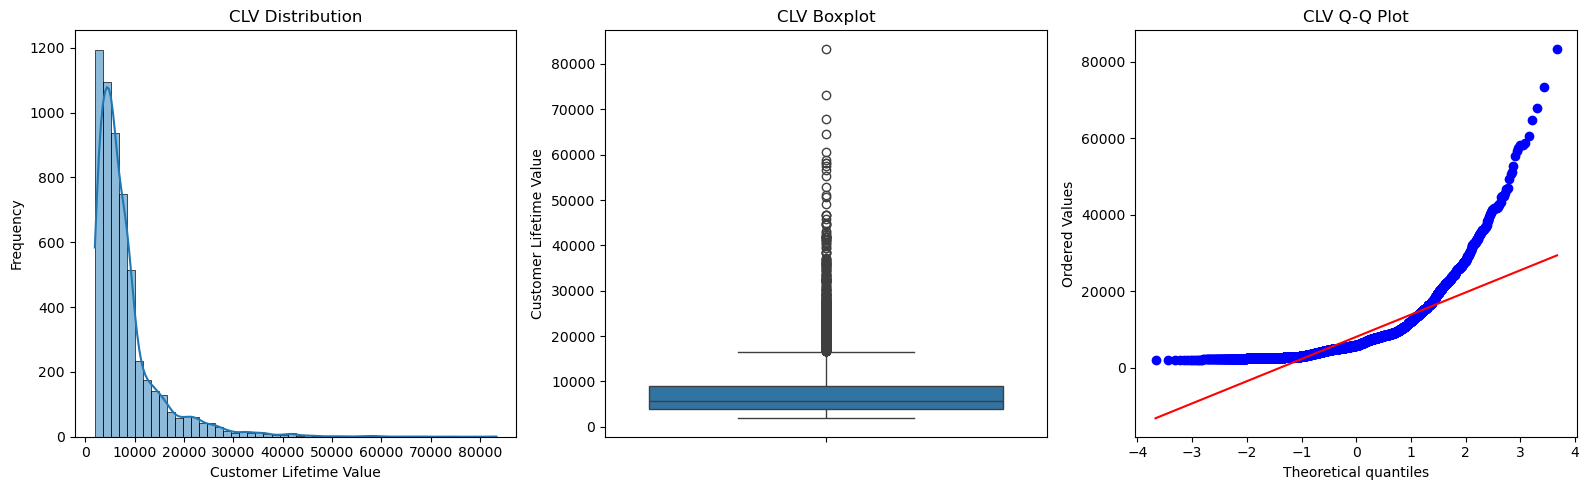

count     5669.000000
mean      8029.874592
std       6916.708246
min       1898.007675
25%       3954.344534
50%       5800.188903
75%       9031.214859
max      83325.381190
Name: Customer Lifetime Value, dtype: float64
Skewness: 3.06
Kurtosis: 14.36


In [56]:
from scipy import stats

target_col = 'Customer Lifetime Value'

plt.figure(figsize=(16, 5))

plt.subplot(1, 3, 1)
sns.histplot(df[target_col], kde=True, bins=50)
plt.title('CLV Distribution')
plt.xlabel('Customer Lifetime Value')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
sns.boxplot(y=df[target_col])
plt.title('CLV Boxplot')
plt.ylabel('Customer Lifetime Value')

plt.subplot(1, 3, 3)
stats.probplot(df[target_col], dist='norm', plot=plt)
plt.title('CLV Q-Q Plot')

plt.tight_layout()
plt.show()

print(df[target_col].describe())
print(f"Skewness: {df[target_col].skew():.2f}")
print(f"Kurtosis: {df[target_col].kurtosis():.2f}")

Berdasarkan histogram, boxplot, dan Q-Q Plot, distribusi **Customer Lifetime Value** terlihat **right-skewed**. Artinya, mayoritas customer memiliki nilai CLV rendah hingga sedang, sedangkan hanya sebagian kecil customer memiliki CLV sangat tinggi.

Dalam konteks bisnis, pola seperti ini cukup wajar karena biasanya hanya sebagian kecil customer yang memberikan kontribusi nilai sangat besar bagi perusahaan. Customer dengan CLV tinggi justru menjadi kelompok penting yang perlu dipertahankan melalui strategi retention, loyalty program, atau personalized offer.

Dari sisi modeling, distribusi target yang skewed dapat membuat model lebih sulit memprediksi customer dengan CLV ekstrem. Karena itu, pada tahap modeling nanti perlu dibandingkan beberapa pendekatan model dan scaler agar hasil prediksi tidak terlalu bias pada nilai ekstrem.

### 5.2 Sebaran Data pada Fitur Numerik

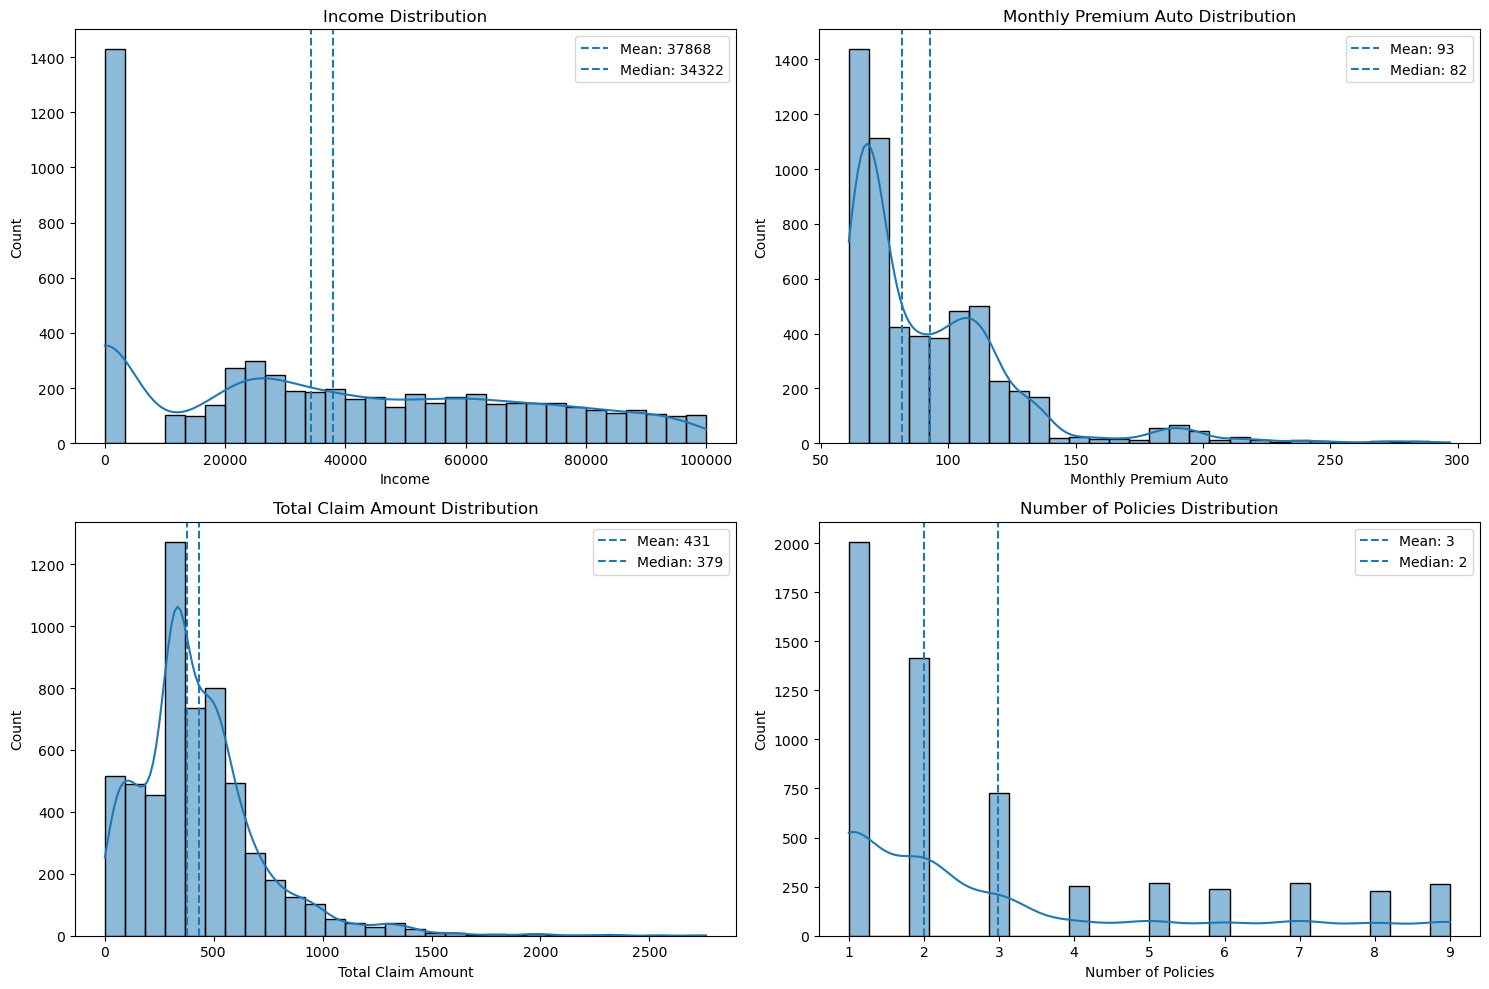

In [10]:
# Kolom numerik utama yang paling relevan untuk dianalisis
main_numerical_cols = [
    col for col in ['Income', 'Monthly Premium Auto', 'Total Claim Amount', 'Number of Policies']
    if col in df.columns
]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for idx, col in enumerate(main_numerical_cols):
    sns.histplot(df[col], kde=True, ax=axes[idx], bins=30)
    axes[idx].set_title(f'{col} Distribution')
    axes[idx].axvline(df[col].mean(), linestyle='--', label=f"Mean: {df[col].mean():.0f}")
    axes[idx].axvline(df[col].median(), linestyle='--', label=f"Median: {df[col].median():.0f}")
    axes[idx].legend()

# Menghapus axis kosong jika jumlah kolom kurang dari 4
for j in range(len(main_numerical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Berdasarkan histogram fitur numerik, beberapa fitur menunjukkan pola **right-skewed**, terutama pada variabel yang berkaitan dengan nilai uang seperti **Monthly Premium Auto** dan **Total Claim Amount**. Hal ini menunjukkan bahwa sebagian besar customer berada pada nilai premi dan klaim rendah hingga sedang, sementara sebagian kecil customer memiliki nilai yang jauh lebih tinggi.

Secara bisnis, pola ini penting karena customer dengan premi tinggi dapat memberikan kontribusi pendapatan yang lebih besar. Namun, customer dengan klaim tinggi juga perlu diperhatikan karena dapat meningkatkan beban biaya perusahaan. Oleh karena itu, fitur premi dan klaim tidak cukup dilihat secara terpisah, tetapi lebih baik juga dibuat menjadi fitur turunan seperti rasio klaim terhadap premi atau selisih premi tahunan dengan klaim.

Pada fitur **Number of Policies**, mayoritas customer cenderung memiliki jumlah polis yang tidak terlalu banyak. Customer dengan jumlah polis lebih besar dapat dianggap sebagai segmen yang memiliki potensi loyalitas dan peluang cross-selling lebih tinggi.

### 5.3 Sebaran Data pada Fitur Kategorikal

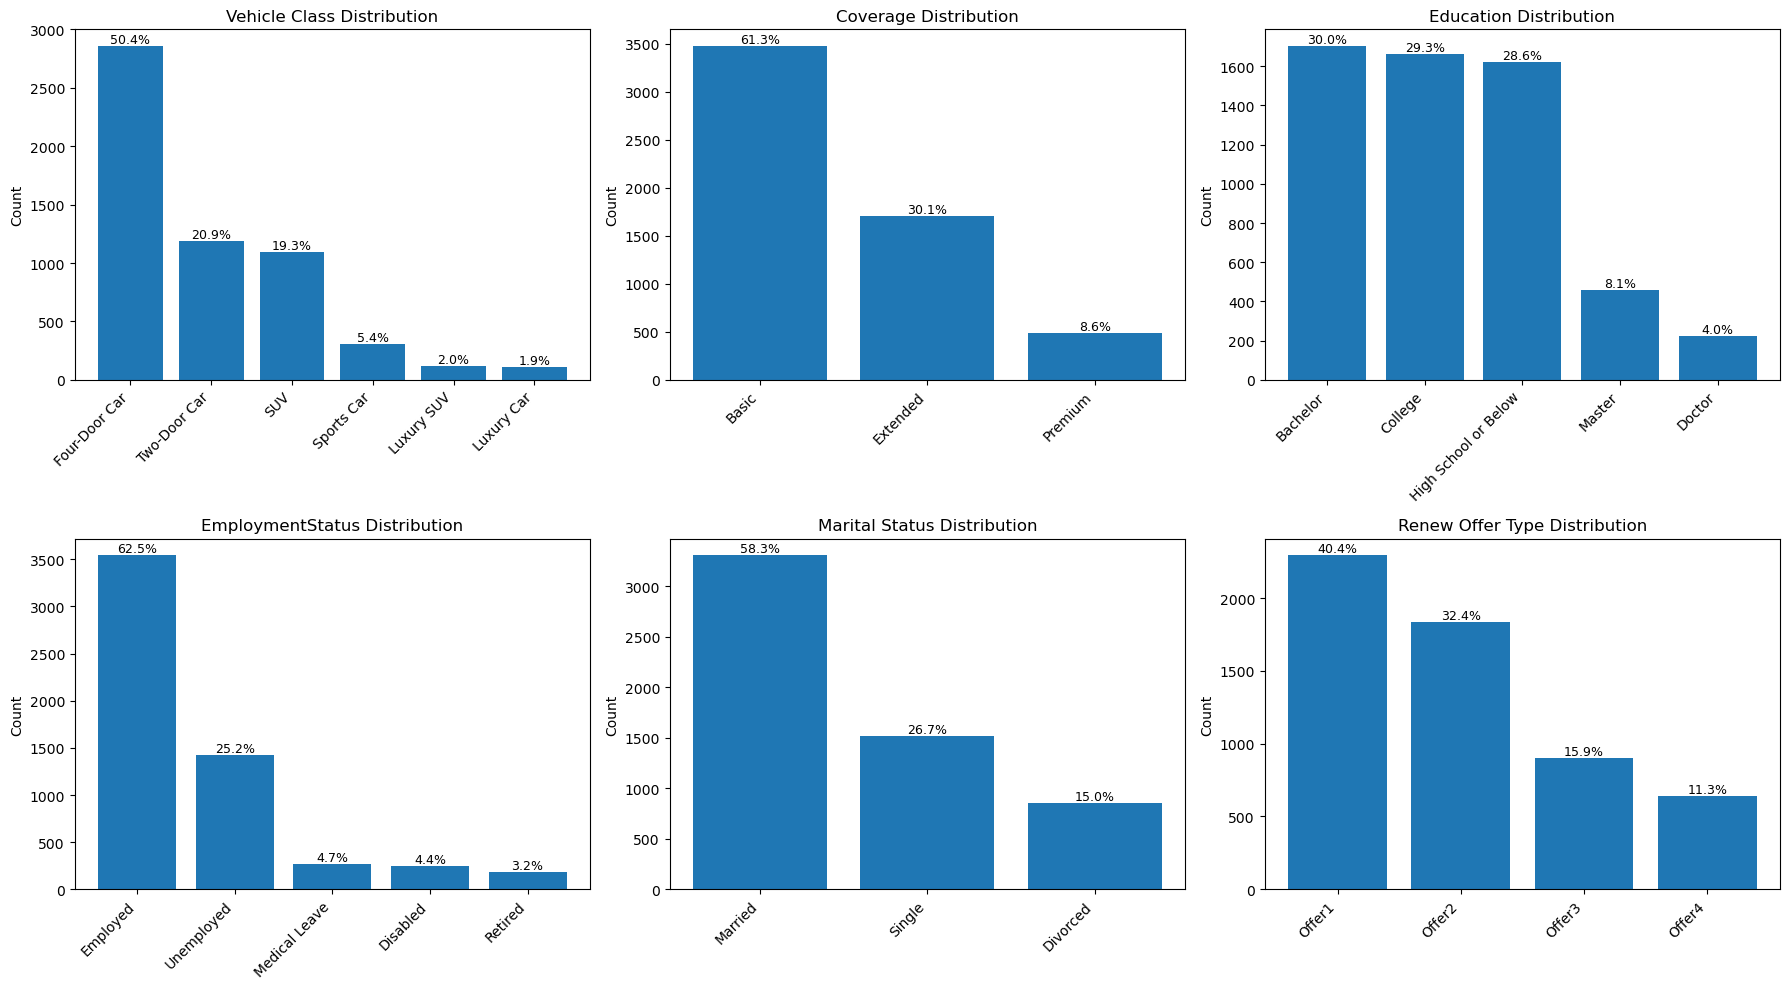

In [11]:
main_categorical_cols = [
    col for col in ['Vehicle Class', 'Coverage', 'Education', 'EmploymentStatus', 'Marital Status', 'Renew Offer Type']
    if col in df.columns
]

n_cols = 3
n_rows = int(np.ceil(len(main_categorical_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = np.array(axes).ravel()

for idx, col in enumerate(main_categorical_cols):
    value_counts = df[col].value_counts()
    axes[idx].bar(range(len(value_counts)), value_counts.values)
    axes[idx].set_xticks(range(len(value_counts)))
    axes[idx].set_xticklabels(value_counts.index, rotation=45, ha='right')
    axes[idx].set_title(f'{col} Distribution')
    axes[idx].set_ylabel('Count')
    
    for i, v in enumerate(value_counts.values):
        pct = (v / len(df)) * 100
        axes[idx].text(i, v, f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)

for j in range(len(main_categorical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Berdasarkan distribusi fitur kategorikal, terlihat bahwa beberapa kategori memiliki dominasi yang cukup kuat. Misalnya, pada fitur **Vehicle Class**, biasanya terdapat kelas kendaraan yang jumlah customernya lebih dominan dibandingkan kategori lainnya. Pada fitur **Coverage**, customer cenderung lebih banyak memilih jenis perlindungan tertentu, terutama coverage yang lebih dasar atau lebih terjangkau.

Dari sisi **EmploymentStatus**, customer yang bekerja dapat menjadi segmen penting karena memiliki kemampuan finansial yang lebih stabil untuk membayar premi. Pada fitur **Marital Status**, customer yang sudah menikah juga dapat menjadi segmen yang relevan karena kebutuhan perlindungan dan keputusan pembelian asuransi dapat berbeda dibanding customer single.

Fitur **Renew Offer Type** penting untuk dianalisis karena berkaitan langsung dengan strategi retensi. Perbedaan jenis penawaran renewal dapat memengaruhi peluang customer bertahan atau melanjutkan polisnya. Secara keseluruhan, fitur kategorikal membantu model menangkap karakteristik customer yang tidak terlihat hanya dari angka numerik.

### 5.4 Hubungan Fitur Numerik dengan Customer Lifetime Value

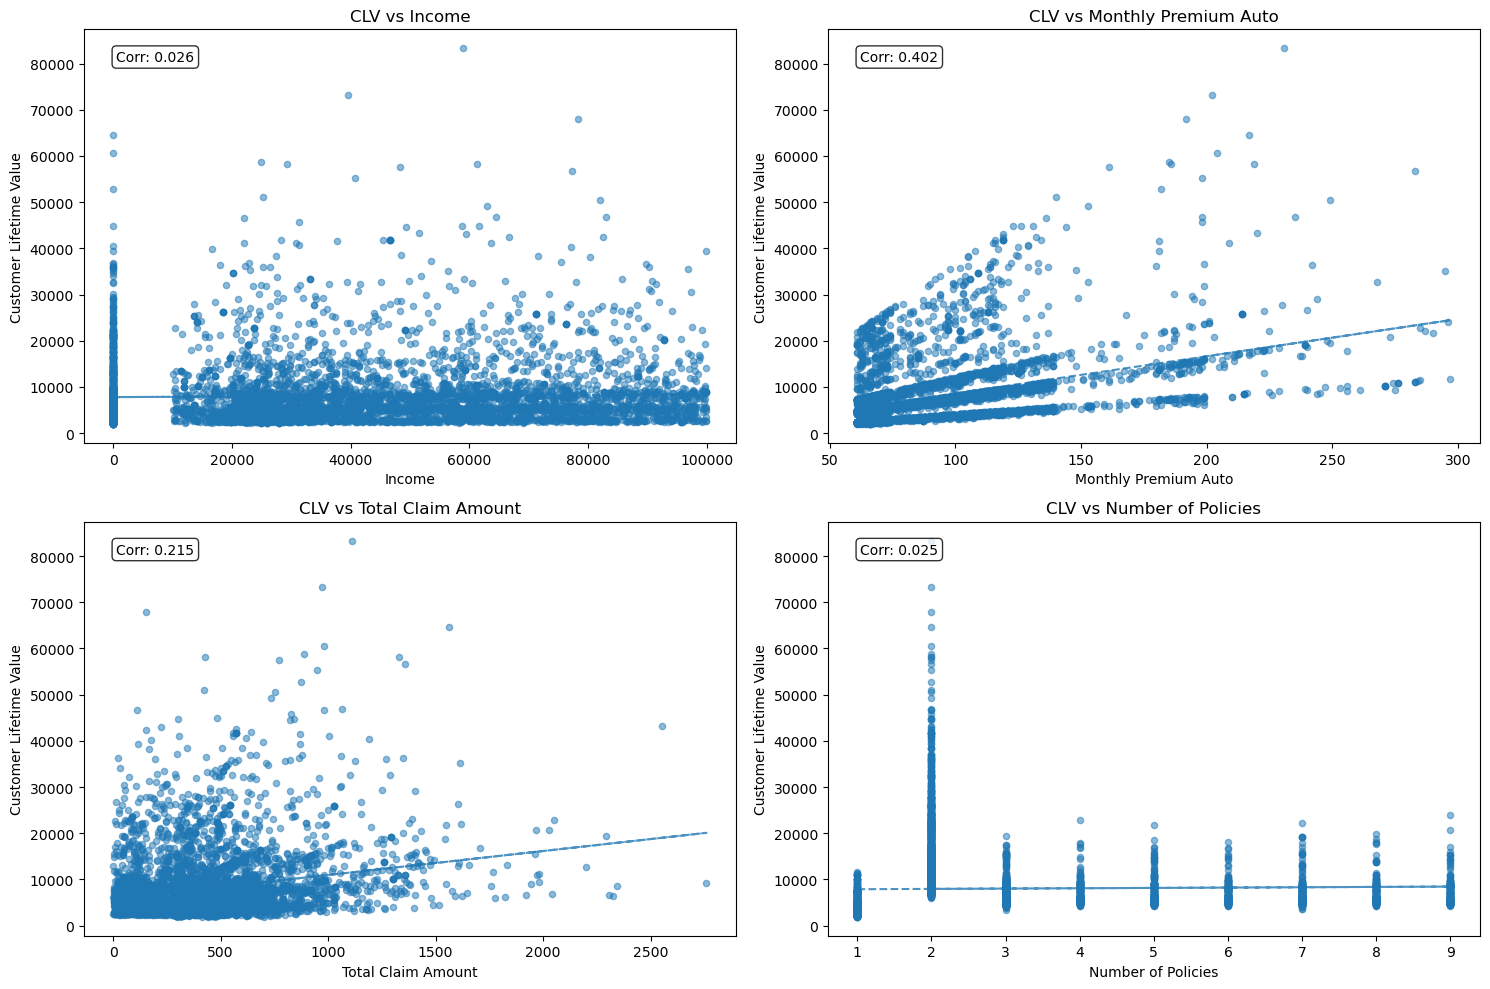

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for idx, col in enumerate(main_numerical_cols):
    axes[idx].scatter(df[col], df[target_col], alpha=0.5, s=20)
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Customer Lifetime Value')
    axes[idx].set_title(f'CLV vs {col}')
    
    if df[col].nunique() > 1:
        z = np.polyfit(df[col], df[target_col], 1)
        p = np.poly1d(z)
        axes[idx].plot(df[col], p(df[col]), linestyle='--', alpha=0.8)
    
    corr = df[col].corr(df[target_col])
    axes[idx].text(
        0.05, 0.95, f'Corr: {corr:.3f}',
        transform=axes[idx].transAxes,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
    )

for j in range(len(main_numerical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Berdasarkan scatter plot, hubungan antara fitur numerik dengan **Customer Lifetime Value** sebagian besar tidak sepenuhnya linear. **Monthly Premium Auto** biasanya menjadi fitur numerik yang paling terlihat hubungannya dengan CLV, karena premi bulanan merupakan salah satu sumber pendapatan utama perusahaan dari customer.

**Total Claim Amount** dapat memiliki hubungan dengan CLV, tetapi interpretasinya perlu hati-hati. Klaim yang tinggi bisa muncul pada customer dengan nilai polis besar, tetapi dari sisi profitabilitas klaim tinggi juga dapat menjadi beban bagi perusahaan. Karena itu, fitur turunan seperti **Claim Premium Ratio** dan **Premium minus Claim** dapat membantu model membaca hubungan antara pendapatan premi dan risiko klaim.

Sementara itu, **Income** dan **Number of Policies** dapat berperan sebagai fitur pendukung. Income menggambarkan kemampuan finansial customer, sedangkan jumlah polis menggambarkan tingkat keterikatan customer dengan perusahaan. Namun, keduanya belum tentu memiliki hubungan linear yang kuat dengan CLV jika berdiri sendiri.

### 5.5 Hubungan Fitur Kategorikal dengan Customer Lifetime Value

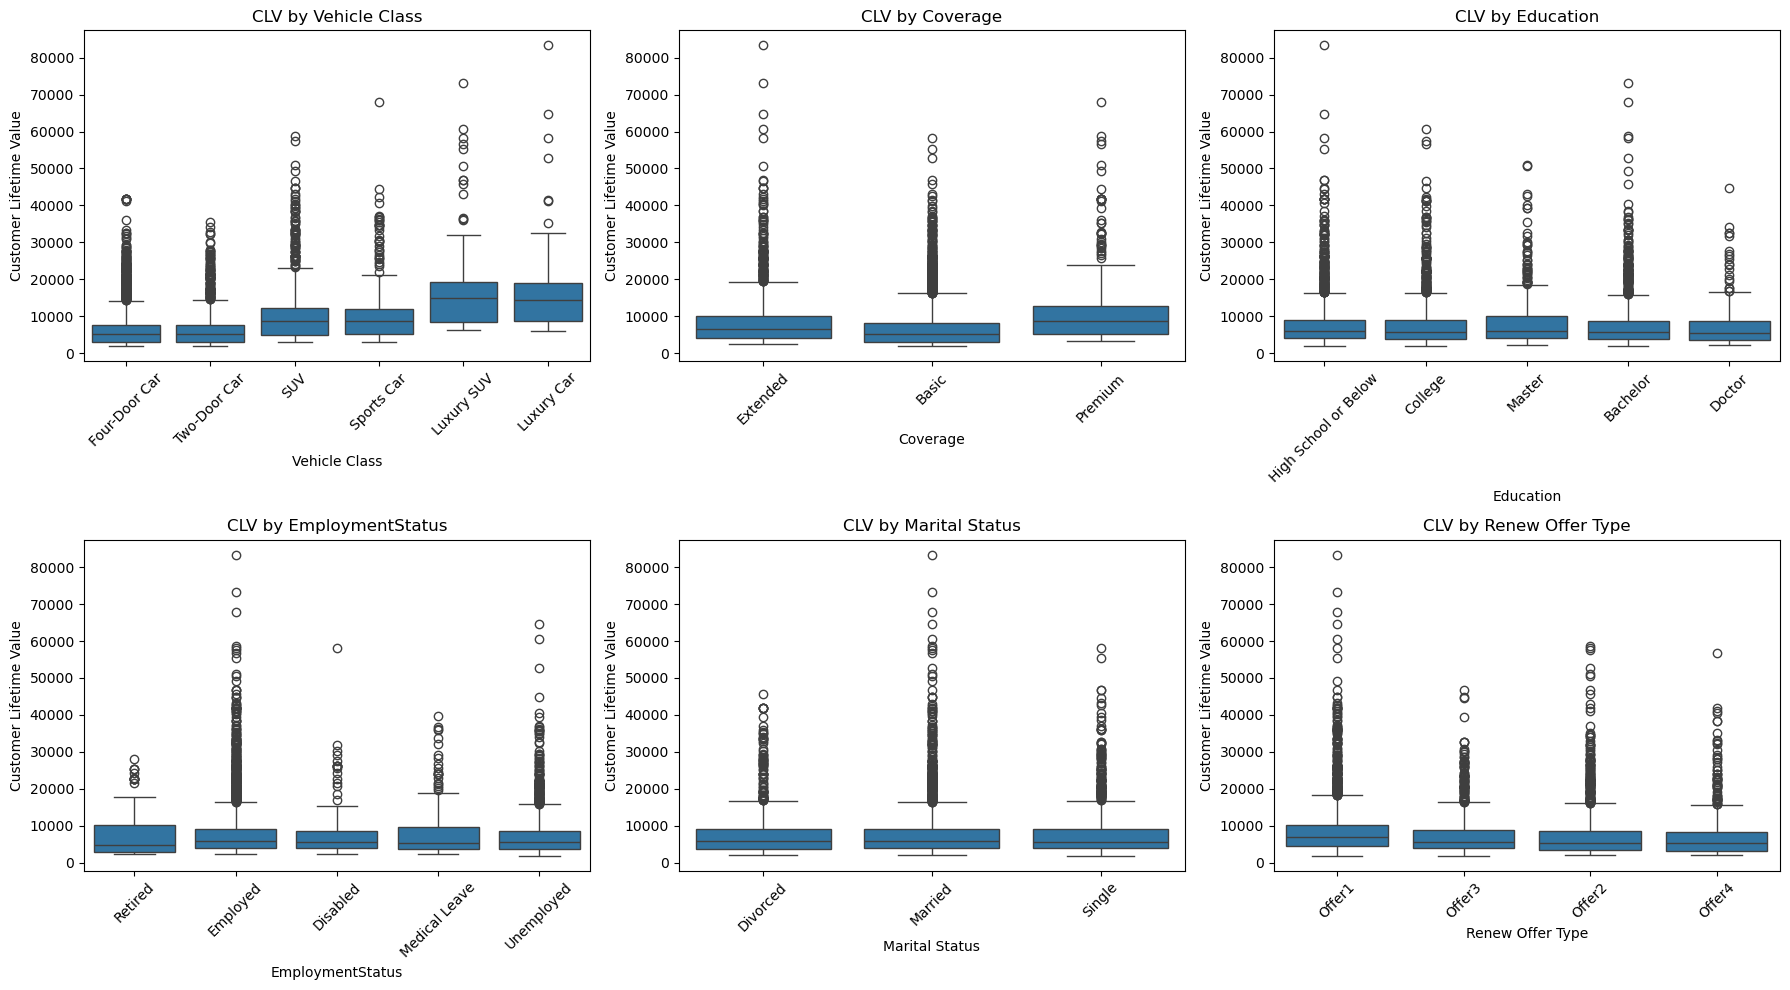

In [13]:
n_cols = 3
n_rows = int(np.ceil(len(main_categorical_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = np.array(axes).ravel()

for idx, col in enumerate(main_categorical_cols):
    sns.boxplot(data=df, x=col, y=target_col, ax=axes[idx])
    axes[idx].set_title(f'CLV by {col}')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Customer Lifetime Value')
    axes[idx].tick_params(axis='x', rotation=45)

for j in range(len(main_categorical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Berdasarkan boxplot CLV pada fitur kategorikal, beberapa kategori dapat memiliki median dan sebaran CLV yang lebih tinggi dibanding kategori lainnya. Contohnya, kategori kendaraan yang lebih mahal atau jenis coverage yang lebih tinggi dapat berkaitan dengan nilai customer yang lebih besar.

Fitur seperti **Vehicle Class**, **Coverage**, dan **Renew Offer Type** cukup penting dari sisi bisnis karena berkaitan dengan jenis produk yang dimiliki customer dan strategi penawaran yang diberikan perusahaan. Jika kategori tertentu memiliki CLV lebih tinggi, maka perusahaan dapat menggunakan insight tersebut untuk menyusun strategi cross-selling, up-selling, atau retention yang lebih tepat.

Namun, karena boxplot hanya menunjukkan pola awal, hasil ini tetap perlu dibuktikan melalui model machine learning. Model dapat menangkap kombinasi pola antarfitur yang tidak terlihat jelas dari visualisasi satu per satu.

### 5.6 Correlation Heatmap

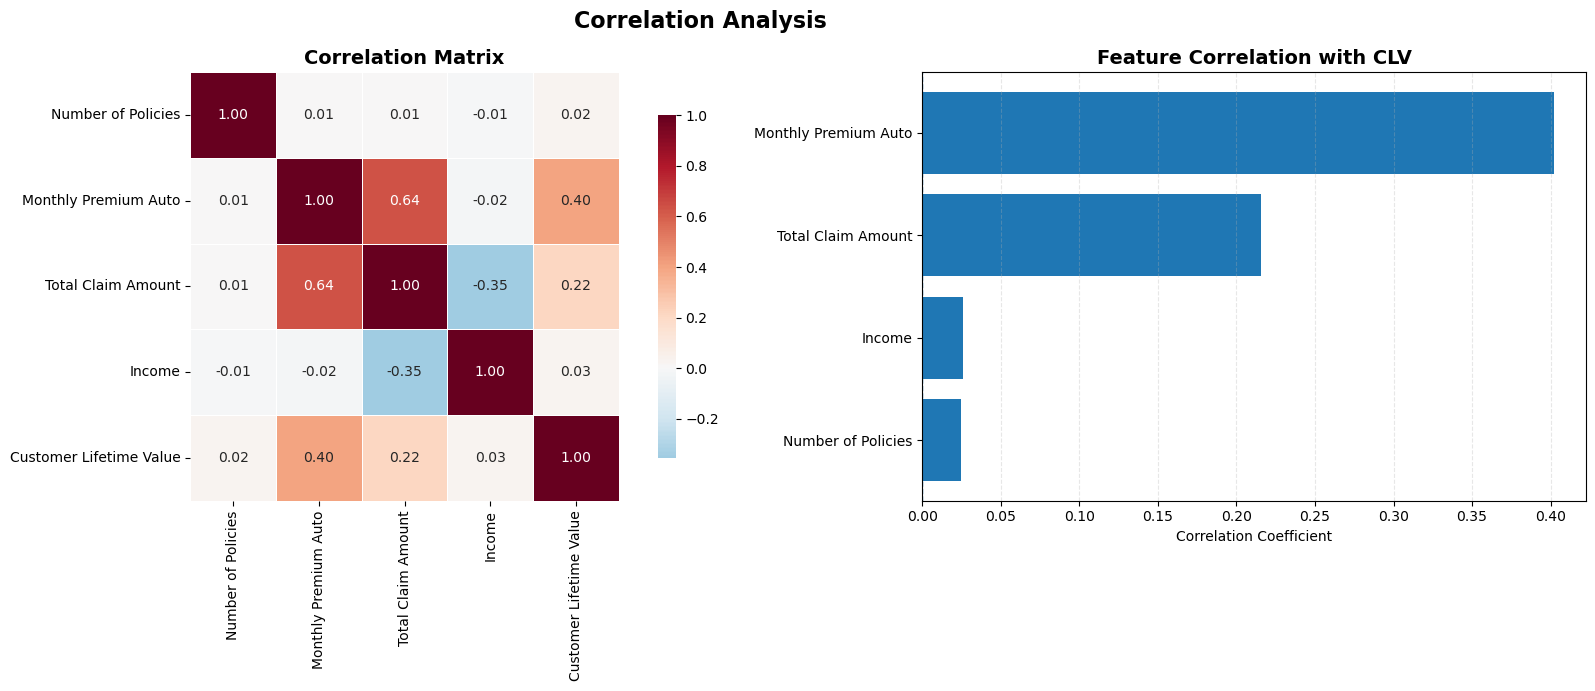

,Correlation with CLV
Number of Policies,0.024721
Income,0.025698
Total Claim Amount,0.215354
Monthly Premium Auto,0.402297


In [14]:
corr_matrix = df.select_dtypes(include=['int64', 'float64']).corr()
target_corr = corr_matrix[target_col].drop(target_col).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(18, 7), gridspec_kw={'width_ratios': [1.2, 1]})

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='RdBu_r',
    center=0,
    fmt='.2f',
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8},
    ax=axes[0]
)
axes[0].set_title('Correlation Matrix', fontsize=14, fontweight='bold')

axes[1].barh(target_corr.index, target_corr.values)
axes[1].axvline(x=0, linestyle='--', linewidth=1)
axes[1].set_title('Feature Correlation with CLV', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Correlation Coefficient')
axes[1].grid(axis='x', linestyle='--', alpha=0.3)

plt.suptitle('Correlation Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

display(target_corr.to_frame('Correlation with CLV'))

Berdasarkan correlation heatmap, fitur numerik dengan korelasi paling tinggi terhadap **Customer Lifetime Value** dapat menjadi kandidat predictor yang penting. Pada data CLV, **Monthly Premium Auto** umumnya memiliki hubungan yang cukup kuat dengan CLV karena premi menggambarkan nilai pembayaran customer kepada perusahaan.

Selain itu, korelasi antarfitur numerik juga perlu diperhatikan untuk melihat potensi **multicollinearity**. Jika ada dua fitur yang memiliki korelasi sangat tinggi, model linear dapat menjadi kurang stabil. Namun, untuk model tree-based seperti Random Forest, Gradient Boosting, XGBoost, dan LightGBM, hubungan non-linear dan interaksi antarfitur masih dapat ditangkap dengan lebih fleksibel.

Walaupun korelasi membantu memahami hubungan linear, fitur dengan korelasi rendah tidak langsung berarti tidak berguna. Fitur tersebut tetap dapat berkontribusi ketika dikombinasikan dengan fitur lain melalui feature engineering atau model non-linear.

## 6. Outlier Detection and Feature Observation

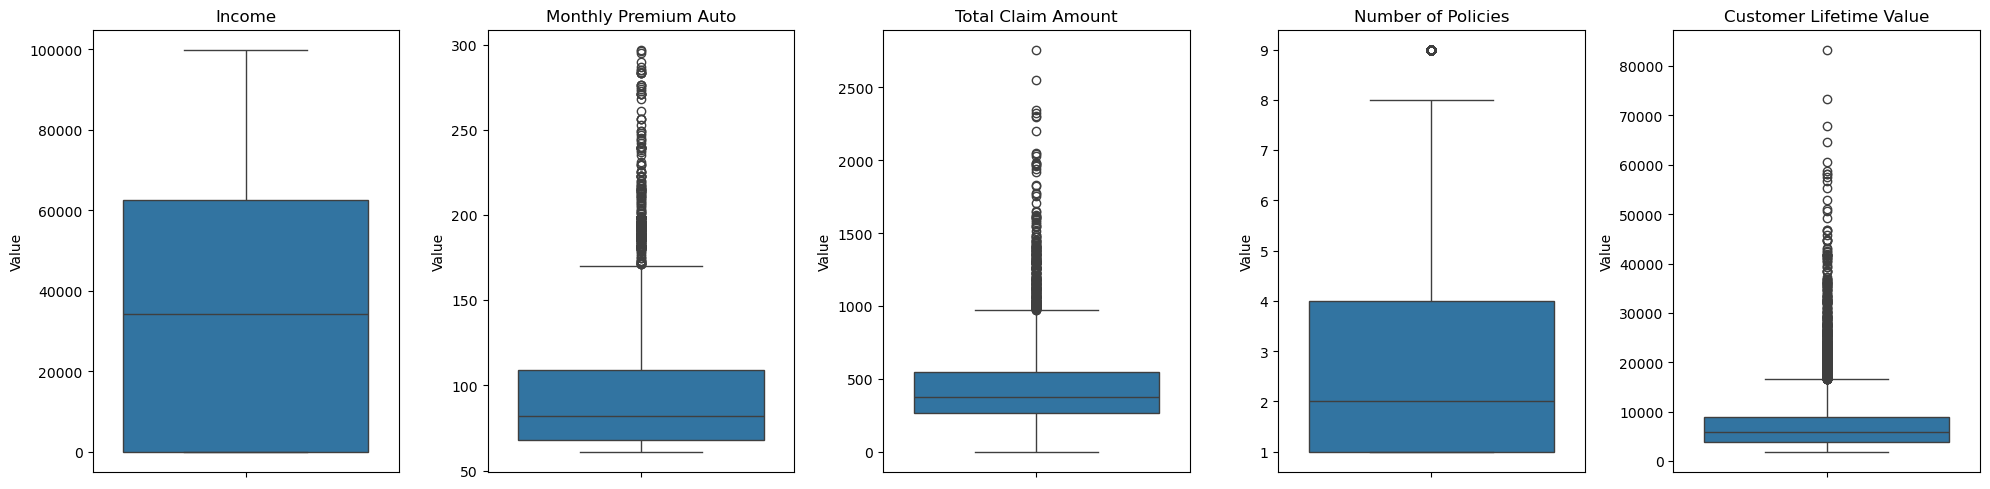

In [15]:
plot_cols = main_numerical_cols + [target_col]

fig, axes = plt.subplots(1, len(plot_cols), figsize=(4 * len(plot_cols), 5))
axes = np.array(axes).ravel()

for idx, col in enumerate(plot_cols):
    sns.boxplot(y=df[col], ax=axes[idx])
    axes[idx].set_title(col)
    axes[idx].set_ylabel('Value')

plt.tight_layout()
plt.show()

In [16]:
# Deteksi outlier menggunakan metode IQR
iqr_rows = []

for col in plot_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outlier_count = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_pct = outlier_count / len(df) * 100
    
    iqr_rows.append({
        'feature': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'lower_bound': lower,
        'upper_bound': upper,
        'outlier_count': outlier_count,
        'outlier_percentage': outlier_pct,
        'skewness': df[col].skew(),
        'kurtosis': df[col].kurtosis()
    })

iqr_summary = pd.DataFrame(iqr_rows)
display(iqr_summary)

,feature,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count,outlier_percentage,skewness,kurtosis
0,Income,0.000000,62464.000000,62464.000000,-93696.000000,156160.000000,0,0.000000,0.282771,-1.101641
1,Monthly Premium Auto,68.000000,109.000000,41.000000,6.500000,170.500000,275,4.850944,2.113224,6.031553
2,Total Claim Amount,266.932542,549.986128,283.053586,-157.647837,974.566507,265,4.674546,1.659885,5.640550
3,Number of Policies,1.000000,4.000000,3.000000,-3.500000,8.500000,264,4.656906,1.240110,0.335236
4,Customer Lifetime Value,3954.344534,9031.214859,5076.870325,-3660.960953,16646.520347,499,8.802258,3.061107,14.355684


In [17]:
# Summary statistik lengkap untuk fitur numerik utama dan target
eda_summary = df[plot_cols].describe().T
eda_summary['skewness'] = df[plot_cols].skew()
eda_summary['kurtosis'] = df[plot_cols].kurtosis()

display(eda_summary)

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
Income,5669.0,37868.188569,30490.490723,0.000000,0.000000,34322.000000,62464.000000,99934.000000,0.282771,-1.101641
Monthly Premium Auto,5669.0,93.026989,34.551795,61.000000,68.000000,82.000000,109.000000,297.000000,2.113224,6.031553
Total Claim Amount,5669.0,431.407103,287.558038,0.423310,266.932542,379.200000,549.986128,2759.794354,1.659885,5.640550
Number of Policies,5669.0,2.979361,2.393187,1.000000,1.000000,2.000000,4.000000,9.000000,1.240110,0.335236
Customer Lifetime Value,5669.0,8029.874592,6916.708246,1898.007675,3954.344534,5800.188903,9031.214859,83325.381190,3.061107,14.355684


### Interpretasi Outlier

Berdasarkan boxplot dan metode IQR, outlier dapat muncul pada **Customer Lifetime Value**, **Monthly Premium Auto**, **Total Claim Amount**, dan **Number of Policies**. Dalam konteks bisnis asuransi, outlier tidak selalu berarti data salah. Customer dengan CLV sangat tinggi, premi tinggi, klaim tinggi, atau jumlah polis banyak masih bisa menjadi kondisi bisnis yang valid.

Pada project ini, outlier tidak langsung dihapus karena dapat mengandung informasi penting, terutama untuk mengenali customer bernilai tinggi. Menghapus outlier CLV terlalu agresif dapat membuat model kehilangan pola customer high-value yang justru penting untuk strategi bisnis.

Sebagai gantinya, model akan dibandingkan menggunakan beberapa pendekatan, seperti scaler yang lebih robust terhadap outlier dan model tree-based yang relatif lebih fleksibel terhadap distribusi data yang tidak normal.

### Interpretasi Detail Fitur Numerik

#### Income

**Hasil Observasi:**  
Income menggambarkan kemampuan finansial customer. Jika terdapat nilai 0 pada income, nilai tersebut perlu diperhatikan karena bisa berarti customer memang tidak memiliki income yang tercatat, atau bisa juga merupakan missing value yang dikodekan sebagai 0.

**Interpretasi Bisnis:**  
Customer dengan income lebih tinggi secara teori memiliki kemampuan lebih besar untuk membayar premi atau membeli produk tambahan. Namun, income belum tentu menjadi faktor utama CLV jika tidak dikombinasikan dengan informasi lain seperti premi, coverage, dan jumlah polis.

**Imbas pada Model:**  
Income tetap digunakan sebagai fitur, tetapi perlu dibuat fitur turunan seperti **Income Premium Ratio** untuk melihat kemampuan customer membayar premi relatif terhadap pendapatannya.

#### Monthly Premium Auto

**Hasil Observasi:**  
Monthly Premium Auto menunjukkan nilai premi bulanan yang dibayarkan customer. Distribusinya dapat cenderung right-skewed karena sebagian kecil customer membayar premi jauh lebih tinggi dibanding mayoritas customer.

**Interpretasi Bisnis:**  
Premi bulanan merupakan salah satu fitur paling penting karena berhubungan langsung dengan pendapatan rutin perusahaan. Customer dengan premi lebih tinggi berpotensi memiliki CLV yang lebih tinggi.

**Imbas pada Model:**  
Fitur ini berpotensi menjadi predictor kuat. Oleh karena itu, fitur turunannya seperti **Annual Premium**, **Premium per Policy**, dan **Premium minus Claim** dapat membantu model memahami nilai customer secara lebih baik.

#### Total Claim Amount

**Hasil Observasi:**  
Total Claim Amount menggambarkan total klaim yang pernah diajukan customer. Nilai klaim tinggi dapat muncul pada sebagian kecil customer dan berpotensi menjadi outlier secara statistik.

**Interpretasi Bisnis:**  
Klaim merupakan beban biaya bagi perusahaan. Customer dengan klaim tinggi belum tentu buruk, tetapi perlu dilihat bersama dengan premi yang dibayarkan. Jika klaim jauh lebih besar dibanding premi, customer tersebut dapat memiliki risiko profitabilitas yang lebih rendah.

**Imbas pada Model:**  
Fitur ini penting, tetapi sebaiknya dikombinasikan dengan premi melalui fitur seperti **Claim Premium Ratio** dan **Claim per Policy**.

#### Number of Policies

**Hasil Observasi:**  
Number of Policies menunjukkan jumlah polis yang dimiliki customer. Mayoritas customer biasanya hanya memiliki sedikit polis, sedangkan sebagian kecil customer memiliki jumlah polis lebih banyak.

**Interpretasi Bisnis:**  
Customer dengan jumlah polis lebih banyak dapat menunjukkan loyalitas atau keterikatan yang lebih tinggi terhadap perusahaan. Hal ini juga dapat menjadi sinyal peluang cross-selling.

**Imbas pada Model:**  
Fitur ini dapat digunakan sebagai fitur pendukung dan dikembangkan menjadi fitur turunan seperti **Is Multi Policy**, **Premium per Policy**, dan **Claim per Policy**.

#### Customer Lifetime Value

**Hasil Observasi:**  
Customer Lifetime Value sebagai target memiliki distribusi yang cenderung right-skewed, dengan sebagian kecil customer memiliki nilai CLV yang sangat tinggi.

**Interpretasi Bisnis:**  
Pola ini menunjukkan bahwa customer tidak memberikan kontribusi yang sama bagi perusahaan. Customer dengan CLV tinggi merupakan segmen yang perlu menjadi prioritas dalam strategi retensi dan marketing.

**Imbas pada Model:**  
Karena target memiliki nilai ekstrem, evaluasi model perlu menggunakan metrik yang mudah dipahami seperti **MAE**, serta metrik tambahan seperti **RMSE** dan **R-squared** untuk melihat kemampuan model menjelaskan variasi CLV.

### Kesimpulan EDA

Dari hasil EDA, terdapat beberapa poin penting yang menjadi dasar proses modeling:

1. **Customer Lifetime Value memiliki distribusi right-skewed**, sehingga sebagian kecil customer memiliki nilai yang sangat tinggi.
2. **Monthly Premium Auto terlihat sebagai salah satu fitur numerik yang paling relevan** karena berhubungan langsung dengan nilai pembayaran customer.
3. **Total Claim Amount perlu dilihat bersama dengan premium**, karena klaim tinggi dapat memengaruhi profitabilitas customer.
4. **Number of Policies dapat menjadi sinyal loyalitas atau peluang cross-selling**, meskipun hubungan langsungnya dengan CLV belum tentu kuat secara linear.
5. **Fitur kategorikal seperti Coverage, Vehicle Class, dan Renew Offer Type tetap penting** karena dapat membedakan karakteristik customer dan produk asuransi yang dimiliki.
6. **Outlier tetap dipertahankan** karena masih valid secara bisnis, terutama untuk customer high-value.
7. **Feature engineering diperlukan** agar model dapat menangkap hubungan bisnis yang lebih kuat, misalnya melalui rasio, interaksi, dan fitur turunan dari premium, claim, income, serta jumlah polis.

## 7. Outlier Handling Decision

Outlier pada dataset tidak dihapus karena nilai ekstrem pada variabel seperti CLV, income, premium, dan claim amount masih dapat merepresentasikan kondisi bisnis yang valid. Dalam konteks CLV, customer dengan nilai sangat tinggi justru merupakan informasi penting karena dapat menunjukkan high-value customer.

Pada project ini, outlier dipertahankan. Untuk mengurangi dampak outlier, akan dibandingkan penggunaan **StandardScaler** dan **RobustScaler**, serta dibandingkan juga performa model linear dan tree-based model.

In [18]:
# Membuat salinan data untuk modeling agar data asli tetap aman
df_model = df.copy()

# Menghapus duplicate sebelum modeling karena baris duplikat tidak menambah informasi baru
print('Jumlah data sebelum drop duplicate:', df_model.shape[0])
df_model = df_model.drop_duplicates().reset_index(drop=True)
print('Jumlah data setelah drop duplicate :', df_model.shape[0])

Jumlah data sebelum drop duplicate: 5669
Jumlah data setelah drop duplicate : 5051


## 8. Split Feature dan Target

Cell ini memisahkan feature dan target. Target yang digunakan adalah `Customer Lifetime Value`.

Target **tidak ditransformasi menggunakan log** agar prediksi tetap berada dalam satuan asli CLV. Dengan begitu, metrik seperti MAE dan RMSE lebih mudah diinterpretasikan secara bisnis.

In [19]:
target = 'Customer Lifetime Value'

X = df_model.drop(columns=target)
y = df_model[target]

print('Feature shape:', X.shape)
print('Target shape :', y.shape)

Feature shape: (5051, 10)
Target shape : (5051,)


## 9. Train-Test Split

Cell ini membagi data menjadi train dan test dengan rasio 80:20. Stratifikasi dilakukan dengan membagi target CLV ke dalam beberapa kelompok agar distribusi nilai CLV pada data train dan test tetap relatif seimbang.

Setelah data dibagi, feature engineering yang bersifat **row-wise** akan dibuat secara terpisah pada data train dan test. Feature engineering yang digunakan hanya memakai variabel input pada baris yang sama, bukan target, sehingga tetap aman dari data leakage. Proses imputation, encoding, dan scaling tetap dimasukkan ke dalam pipeline agar hanya `fit` pada data train.

In [20]:
y_bins = pd.qcut(y, q=5, labels=False, duplicates='drop')

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y_bins
)

print('X_train shape:', X_train.shape)
print('X_test shape :', X_test.shape)

print('\nDistribusi target:')
print(f'Train mean: {y_train.mean():.2f}')
print(f'Test mean : {y_test.mean():.2f}')
print(f'Train std : {y_train.std():.2f}')
print(f'Test std  : {y_test.std():.2f}')

X_train shape: (4040, 10)
X_test shape : (1011, 10)

Distribusi target:
Train mean: 7987.09
Test mean : 8348.77
Train std : 6668.64
Test std  : 8142.50


## 10. Feature Engineering dengan Function Sederhana

Cell ini membuat feature tambahan menggunakan function biasa, bukan menggunakan `class` atau custom transformer. Format ini dipilih agar kode tetap natural dan mudah dipahami karena alurnya masih mengikuti materi Pandas, function, preprocessing, dan machine learning dasar.

Feature yang dibuat hanya berasal dari variabel input seperti premium, claim, income, dan jumlah polis. Tidak ada feature yang dibuat dari target `Customer Lifetime Value`, sehingga risiko data leakage tetap dihindari.

In [21]:
def add_clv_features(data):
    df_new = data.copy()
    
    # Annual premium dihitung dari monthly premium.
    df_new['Annual_Premium'] = df_new['Monthly Premium Auto'] * 12
    
    # Menghindari pembagian dengan angka 0.
    policies = df_new['Number of Policies'].replace(0, np.nan)
    income = df_new['Income'].replace(0, np.nan)
    annual_premium = df_new['Annual_Premium'].replace(0, np.nan)
    
    # Feature dasar dari premium dan jumlah polis.
    df_new['Premium_per_Policy'] = df_new['Monthly Premium Auto'] / policies
    df_new['Is_Multi_Policy'] = np.where(df_new['Number of Policies'] > 1, 1, 0)
    
    # Feature profitabilitas dan risiko klaim.
    df_new['Claim_Premium_Ratio'] = df_new['Total Claim Amount'] / annual_premium
    df_new['Premium_minus_Claim'] = df_new['Annual_Premium'] - df_new['Total Claim Amount']
    df_new['Claim_per_Policy'] = df_new['Total Claim Amount'] / policies
    
    # Feature affordability berdasarkan income.
    df_new['Income_Premium_Ratio'] = df_new['Income'] / annual_premium
    df_new['Premium_Income_Pct'] = df_new['Annual_Premium'] / income
    df_new['Claim_Income_Pct'] = df_new['Total Claim Amount'] / income
    
    # Feature interaksi sederhana.
    df_new['Policy_Premium_Interaction'] = df_new['Number of Policies'] * df_new['Monthly Premium Auto']
    
    # Mengganti nilai infinite menjadi missing value agar nanti ditangani imputer.
    df_new = df_new.replace([np.inf, -np.inf], np.nan)
    
    return df_new


X_train_fe = add_clv_features(X_train)
X_test_fe = add_clv_features(X_test)

print('Jumlah kolom sebelum feature engineering:', X_train.shape[1])
print('Jumlah kolom setelah feature engineering :', X_train_fe.shape[1])

X_train_fe.head()

Jumlah kolom sebelum feature engineering: 10
Jumlah kolom setelah feature engineering : 20


,Vehicle Class,Coverage,Renew Offer Type,EmploymentStatus,Marital Status,Education,Number of Policies,Monthly Premium Auto,Total Claim Amount,Income,Annual_Premium,Premium_per_Policy,Is_Multi_Policy,Claim_Premium_Ratio,Premium_minus_Claim,Claim_per_Policy,Income_Premium_Ratio,Premium_Income_Pct,Claim_Income_Pct,Policy_Premium_Interaction
3549,Four-Door Car,Extended,Offer1,Unemployed,Married,College,2.0,90.0,432.0,0.0,1080.0,45.000000,1,0.4,648.0,216.00,0.000000,NaN,NaN,180.0
4717,SUV,Extended,Offer1,Unemployed,Single,High School or Below,2.0,126.0,907.2,0.0,1512.0,63.000000,1,0.6,604.8,453.60,0.000000,NaN,NaN,252.0
161,Four-Door Car,Basic,Offer3,Employed,Married,Bachelor,1.0,62.0,297.6,27615.0,744.0,62.000000,0,0.4,446.4,297.60,37.116935,0.026942,0.010777,62.0
2790,Four-Door Car,Basic,Offer4,Employed,Married,High School or Below,5.0,66.0,316.8,90217.0,792.0,13.200000,1,0.4,475.2,63.36,113.910354,0.008779,0.003512,330.0
825,Four-Door Car,Basic,Offer1,Unemployed,Single,College,3.0,73.0,525.6,0.0,876.0,24.333333,1,0.6,350.4,175.20,0.000000,NaN,NaN,219.0


## 11. Definisi Kolom untuk Preprocessing

Cell ini mengelompokkan kolom sesuai jenis preprocessing yang dibutuhkan:

- Continuous numerical features: imputation + scaling
- Binary features: imputation saja
- Ordinal categorical features: ordinal encoding
- Nominal categorical features: one-hot encoding

In [22]:
continuous_features = [
    'Number of Policies',
    'Monthly Premium Auto',
    'Total Claim Amount',
    'Income',
    'Annual_Premium',
    'Claim_Premium_Ratio',
    'Income_Premium_Ratio',
    'Premium_per_Policy',
    'Premium_minus_Claim',
    'Claim_per_Policy',
    'Premium_Income_Pct',
    'Claim_Income_Pct',
    'Policy_Premium_Interaction'
]

binary_features = [
    'Is_Multi_Policy'
]

ordinal_features = [
    'Coverage',
    'Education'
]

nominal_features = [
    'Vehicle Class',
    'Renew Offer Type',
    'EmploymentStatus',
    'Marital Status'
]

coverage_order = ['Basic', 'Extended', 'Premium']
education_order = ['High School or Below', 'College', 'Bachelor', 'Master', 'Doctor']

### Catatan Feature Tambahan

Feature tambahan seperti `Premium_minus_Claim`, `Claim_per_Policy`, `Premium_Income_Pct`, `Claim_Income_Pct`, dan `Policy_Premium_Interaction` digunakan untuk mencoba menangkap aspek profitabilitas, risiko klaim, affordability, serta interaksi antara jumlah polis dan premium.

Semua feature tersebut aman digunakan karena hanya berasal dari variabel input. Tidak ada feature yang dibuat dari target `Customer Lifetime Value`, sehingga risiko data leakage tetap dihindari. Kode juga sengaja dibuat dengan function sederhana agar lebih sesuai dengan alur pembelajaran yang belum menggunakan konsep `class` atau OOP.

## 12. Function untuk Membuat Preprocessor

Cell ini membuat function preprocessing. Scaler dibuat fleksibel agar dapat dibandingkan antara **StandardScaler** dan **RobustScaler**.

Preprocessing disimpan dalam pipeline agar proses imputation, encoding, dan scaling hanya `fit` pada data train.

In [23]:
def make_onehot_encoder():
    # Membuat OneHotEncoder yang kompatibel dengan beberapa versi scikit-learn
    try:
        return OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
    except TypeError:
        return OneHotEncoder(drop='first', handle_unknown='ignore', sparse=False)


def build_preprocessor(scaler):
    continuous_pipe = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', scaler)
    ])
    
    binary_pipe = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent'))
    ])
    
    ordinal_pipe = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OrdinalEncoder(
            categories=[coverage_order, education_order],
            handle_unknown='use_encoded_value',
            unknown_value=-1
        ))
    ])
    
    nominal_pipe = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', make_onehot_encoder())
    ])
    
    preprocessor = ColumnTransformer(transformers=[
        ('continuous', continuous_pipe, continuous_features),
        ('binary', binary_pipe, binary_features),
        ('ordinal', ordinal_pipe, ordinal_features),
        ('nominal', nominal_pipe, nominal_features)
    ])
    
    return preprocessor

## 13. Function Evaluasi Regresi

Cell ini membuat function untuk menghitung metrik regresi. Metrik yang digunakan:

- **MAE**: metrik utama karena mudah dijelaskan dalam satuan CLV.
- **RMSE**: melihat penalti terhadap error besar.
- **R-squared**: melihat seberapa besar variasi target yang dapat dijelaskan model.

In [24]:
def evaluate_regression(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    return mae, rmse, r2

## 14. Baseline Model

Cell ini membuat baseline model menggunakan `DummyRegressor`. Baseline digunakan sebagai pembanding paling sederhana. Model machine learning dianggap bermanfaat apabila performanya lebih baik dari baseline.

In [25]:
cv = KFold(n_splits=3, shuffle=True, random_state=42)

baseline = DummyRegressor(strategy='mean')

baseline_cv = cross_validate(
    baseline,
    X_train,
    y_train,
    cv=cv,
    scoring={
        'MAE': 'neg_mean_absolute_error',
        'MSE': 'neg_mean_squared_error',
        'R2': 'r2'
    }
)

baseline_result = pd.DataFrame({
    'Model': ['Baseline Mean'],
    'CV_MAE': [-baseline_cv['test_MAE'].mean()],
    'CV_RMSE': [np.sqrt(-baseline_cv['test_MSE'].mean())],
    'CV_R2': [baseline_cv['test_R2'].mean()]
})

baseline_result

,Model,CV_MAE,CV_RMSE,CV_R2
0,Baseline Mean,4386.759038,6667.899112,-0.000025


## 15. Daftar Model dan Scaler yang Dibandingkan

Cell ini mendefinisikan model dan scaler yang akan dibandingkan.

Model linear digunakan sebagai pembanding yang lebih sederhana dan interpretatif. Tree-based model digunakan karena mampu menangkap pola non-linear dan interaksi antar feature.

In [26]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(random_state=42),
    'Lasso': Lasso(random_state=42, max_iter=3000, tol=0.01),
    'Decision Tree': DecisionTreeRegressor(
        random_state=42,
        max_depth=8,
        min_samples_leaf=10
    ),
    'Random Forest': RandomForestRegressor(
        random_state=42,
        n_estimators=100,
        max_depth=12,
        min_samples_leaf=5,
        n_jobs=1
    ),
    'Gradient Boosting': GradientBoostingRegressor(
        random_state=42,
        n_estimators=100,
        learning_rate=0.05,
        max_depth=3
    ),
    'XGBoost': XGBRegressor(
        random_state=42,
        n_estimators=150,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='reg:squarederror',
        n_jobs=1,
        verbosity=0
    ),
    'Random Forest Log Target': TransformedTargetRegressor(
        regressor=RandomForestRegressor(
            random_state=42,
            n_estimators=100,
            max_depth=12,
            min_samples_leaf=5,
            n_jobs=1
        ),
        func=np.log1p,
        inverse_func=np.expm1
    ),
    'XGBoost Log Target': TransformedTargetRegressor(
        regressor=XGBRegressor(
            random_state=42,
            n_estimators=150,
            learning_rate=0.05,
            max_depth=3,
            subsample=0.8,
            colsample_bytree=0.8,
            objective='reg:squarederror',
            n_jobs=1,
            verbosity=0
        ),
        func=np.log1p,
        inverse_func=np.expm1
    )
}

scalers = {
    'StandardScaler': StandardScaler(),
    'RobustScaler': RobustScaler()
}

model_family = {
    'Linear Regression': 'Linear Model',
    'Ridge': 'Linear Model',
    'Lasso': 'Linear Model',
    'Decision Tree': 'Tree-Based Model',
    'Random Forest': 'Tree-Based Model',
    'Gradient Boosting': 'Boosting Model',
    'XGBoost': 'Boosting Model',
    'Random Forest Log Target': 'Log-Target Tree Model',
    'XGBoost Log Target': 'Log-Target Boosting Model'
}

### Catatan Tambahan: XGBoost dan Target Transformation

XGBoost adalah salah satu algoritma boosting yang sering digunakan pada data tabular. XGBoost membangun model secara bertahap, di mana setiap tree baru berusaha memperbaiki error dari tree sebelumnya.

Pada versi ini, juga ditambahkan eksperimen **Log Target** menggunakan `TransformedTargetRegressor`. Pendekatan ini berbeda dengan membuat `CLV_log` sebagai feature. Target boleh ditransformasi dalam proses training, lalu hasil prediksi dikembalikan lagi ke skala asli menggunakan inverse transform. Dengan cara ini, evaluasi MAE, RMSE, dan R-squared tetap dibaca dalam satuan CLV asli.

## 16. Perbandingan Model dengan StandardScaler, RobustScaler, dan Log Target

Cell ini membandingkan seluruh kombinasi model dan scaler menggunakan cross-validation pada data train yang sudah ditambahkan feature engineering sederhana.

Pemilihan model terbaik didasarkan pada **CV_MAE** karena MAE menjadi metrik utama. Test set tetap disimpan untuk evaluasi final agar tidak terjadi data leakage.

In [27]:
comparison_results = []

for scaler_name, scaler in scalers.items():
    for model_name, model in models.items():
        pipeline = Pipeline(steps=[
            ('preprocessing', build_preprocessor(scaler)),
            ('model', model)
        ])
        
        cv_scores = cross_validate(
            pipeline,
            X_train_fe,
            y_train,
            cv=cv,
            scoring={
                'MAE': 'neg_mean_absolute_error',
                'MSE': 'neg_mean_squared_error',
                'R2': 'r2'
            },
            n_jobs=1
        )
        
        comparison_results.append({
            'Scaler': scaler_name,
            'Model': model_name,
            'Family': model_family[model_name],
            'CV_MAE': -cv_scores['test_MAE'].mean(),
            'CV_RMSE': np.sqrt(-cv_scores['test_MSE'].mean()),
            'CV_R2': cv_scores['test_R2'].mean()
        })

results_df = pd.DataFrame(comparison_results)
results_df = results_df.sort_values(by='CV_MAE').reset_index(drop=True)

results_df

,Scaler,Model,Family,CV_MAE,CV_RMSE,CV_R2
0,StandardScaler,Random Forest Log Target,Log-Target Tree Model,1534.268657,3819.110260,0.671584
1,RobustScaler,Random Forest Log Target,Log-Target Tree Model,1535.512444,3827.832055,0.670057
2,StandardScaler,XGBoost Log Target,Log-Target Boosting Model,1557.600049,3783.412460,0.677853
3,RobustScaler,XGBoost Log Target,Log-Target Boosting Model,1562.394575,3790.681459,0.676563
4,RobustScaler,Random Forest,Tree-Based Model,1615.485267,3793.317896,0.675914
5,StandardScaler,Random Forest,Tree-Based Model,1617.261243,3796.927691,0.675347
6,StandardScaler,Decision Tree,Tree-Based Model,1700.660359,4050.612084,0.630304
7,RobustScaler,Decision Tree,Tree-Based Model,1704.215789,4048.527082,0.630774
8,StandardScaler,XGBoost,Boosting Model,1752.581679,3760.426821,0.681753
9,RobustScaler,XGBoost,Boosting Model,1754.943102,3768.272531,0.680370


## 17. Perbandingan Sebelum dan Sesudah XGBoost / Log Target

Cell ini membandingkan hasil terbaik sebelum menggunakan XGBoost, setelah XGBoost ditambahkan, dan setelah eksperimen log target ikut dicoba. Tujuannya untuk melihat apakah pendekatan tambahan benar-benar meningkatkan performa, bukan hanya menambah kompleksitas model.

In [28]:
# Membandingkan performa terbaik sebelum dan sesudah XGBoost serta log target.
# Dasar pemilihan tetap menggunakan CV_MAE karena MAE adalah metrik utama.

regular_models = ['Linear Regression', 'Ridge', 'Lasso', 'Decision Tree', 'Random Forest', 'Gradient Boosting']
xgboost_models = ['XGBoost']
log_target_models = ['Random Forest Log Target', 'XGBoost Log Target']

best_before_xgboost = results_df[results_df['Model'].isin(regular_models)].sort_values('CV_MAE').iloc[0]
best_with_xgboost = results_df[results_df['Model'].isin(regular_models + xgboost_models)].sort_values('CV_MAE').iloc[0]
best_after_all = results_df.sort_values('CV_MAE').iloc[0]

before_after_xgb = pd.DataFrame([
    {
        'Scenario': 'Before XGBoost',
        'Best_Model': best_before_xgboost['Model'],
        'Scaler': best_before_xgboost['Scaler'],
        'CV_MAE': best_before_xgboost['CV_MAE'],
        'CV_RMSE': best_before_xgboost['CV_RMSE'],
        'CV_R2': best_before_xgboost['CV_R2']
    },
    {
        'Scenario': 'After XGBoost',
        'Best_Model': best_with_xgboost['Model'],
        'Scaler': best_with_xgboost['Scaler'],
        'CV_MAE': best_with_xgboost['CV_MAE'],
        'CV_RMSE': best_with_xgboost['CV_RMSE'],
        'CV_R2': best_with_xgboost['CV_R2']
    },
    {
        'Scenario': 'After XGBoost + Log Target',
        'Best_Model': best_after_all['Model'],
        'Scaler': best_after_all['Scaler'],
        'CV_MAE': best_after_all['CV_MAE'],
        'CV_RMSE': best_after_all['CV_RMSE'],
        'CV_R2': best_after_all['CV_R2']
    }
])

before_after_xgb

,Scenario,Best_Model,Scaler,CV_MAE,CV_RMSE,CV_R2
0,Before XGBoost,Random Forest,RobustScaler,1615.485267,3793.317896,0.675914
1,After XGBoost,Random Forest,RobustScaler,1615.485267,3793.317896,0.675914
2,After XGBoost + Log Target,Random Forest Log Target,StandardScaler,1534.268657,3819.110260,0.671584


### Interpretasi Perbandingan Tambahan

Jika nilai CV_MAE pada skenario setelah XGBoost atau setelah log target lebih rendah, maka pendekatan tambahan tersebut memberi peningkatan performa. Namun, jika model terbaik tetap berasal dari model sebelumnya, maka pendekatan tambahan belum menjadi pilihan terbaik untuk dataset ini.

Eksperimen ini tetap penting karena menunjukkan bahwa pemilihan model dilakukan berdasarkan perbandingan performa, bukan hanya asumsi bahwa model yang lebih kompleks pasti lebih baik.

## 17. Perbandingan StandardScaler vs RobustScaler

StandardScaler menggunakan mean dan standard deviation, sehingga lebih sensitif terhadap outlier. RobustScaler menggunakan median dan IQR, sehingga secara teori lebih tahan terhadap outlier.

Cell ini merangkum rata-rata performa masing-masing scaler dari seluruh model yang diuji.

In [29]:
scaler_comparison = (
    results_df
    .groupby('Scaler')[['CV_MAE', 'CV_RMSE', 'CV_R2']]
    .mean()
    .sort_values(by='CV_MAE')
)

scaler_comparison

,CV_MAE,CV_RMSE,CV_R2
Scaler,,,
StandardScaler,2053.266494,4101.081838,0.618019
RobustScaler,2054.814627,4103.343744,0.617627


## 19. Perbandingan Linear Model, Tree-Based Model, Boosting Model, dan Log-Target Model

Cell ini membandingkan efektivitas rata-rata antar kelompok model.

Linear model cenderung sederhana dan mudah diinterpretasikan, tetapi lebih terbatas dalam menangkap hubungan non-linear. Tree-based dan boosting model lebih fleksibel untuk data tabular. Sementara itu, log-target model dicoba untuk menangani distribusi CLV yang cenderung skewed, tetapi hasilnya tetap dievaluasi pada skala CLV asli.

In [30]:
family_comparison = (
    results_df
    .groupby('Family')[['CV_MAE', 'CV_RMSE', 'CV_R2']]
    .mean()
    .sort_values(by='CV_MAE')
)

family_comparison

,CV_MAE,CV_RMSE,CV_R2
Family,,,
Log-Target Tree Model,1534.890551,3823.471158,0.670820
Log-Target Boosting Model,1559.997312,3787.046959,0.677208
Tree-Based Model,1659.405665,3922.346188,0.653085
Boosting Model,1759.111432,3768.643791,0.680335
Linear Model,2851.480997,4642.472348,0.515179


## 19. Visualisasi Perbandingan Model

Cell ini menampilkan perbandingan nilai CV MAE dari setiap kombinasi model dan scaler. Semakin kecil nilai MAE, semakin baik performa model.

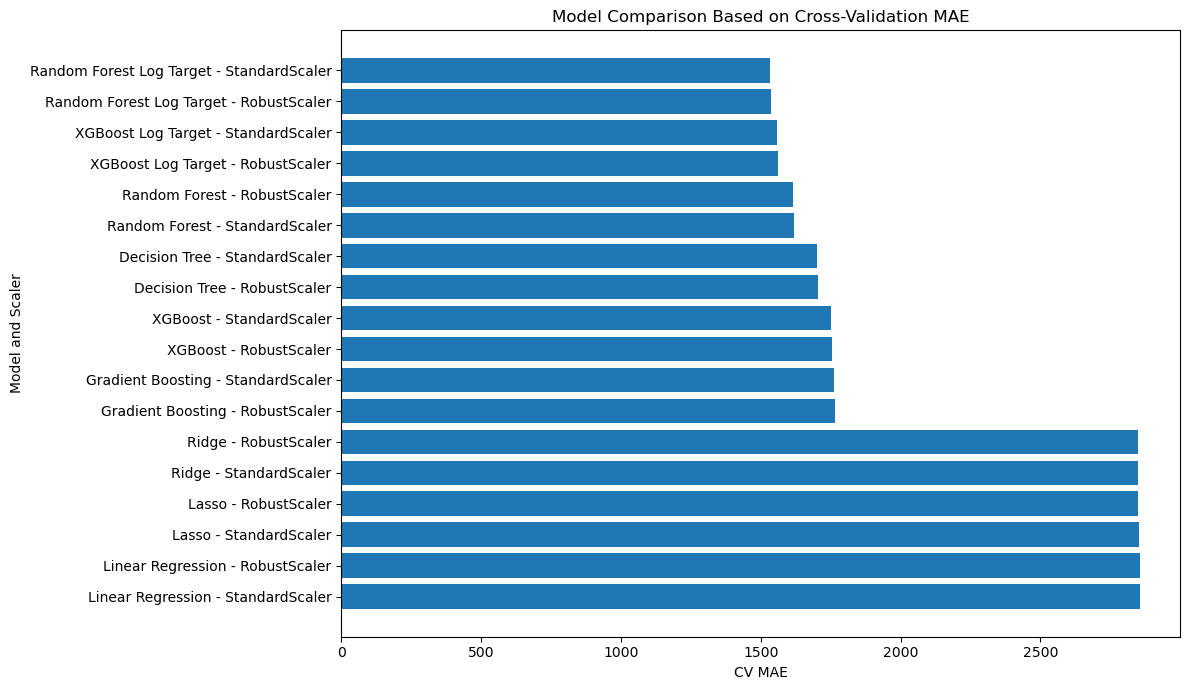

In [31]:
plot_df = results_df.sort_values('CV_MAE', ascending=True).copy()
plot_df['Label'] = plot_df['Model'] + ' - ' + plot_df['Scaler']

plt.figure(figsize=(12, 7))
plt.barh(plot_df['Label'], plot_df['CV_MAE'])
plt.gca().invert_yaxis()
plt.title('Model Comparison Based on Cross-Validation MAE')
plt.xlabel('CV MAE')
plt.ylabel('Model and Scaler')
plt.tight_layout()
plt.show()

## 20. Pilih Kandidat Model Terbaik

Cell ini memilih model terbaik berdasarkan nilai CV_MAE terkecil. Hasil ini digunakan sebagai dasar untuk hyperparameter tuning.

In [32]:
best_row = results_df.sort_values(by='CV_MAE').iloc[0]

best_scaler_name = best_row['Scaler']
best_model_name = best_row['Model']

print('Best scaler:', best_scaler_name)
print('Best model :', best_model_name)
print('\nBest CV result:')
display(best_row.to_frame().T)

Best scaler: StandardScaler
Best model : Random Forest Log Target

Best CV result:


,Scaler,Model,Family,CV_MAE,CV_RMSE,CV_R2
0,StandardScaler,Random Forest Log Target,Log-Target Tree Model,1534.268657,3819.11026,0.671584


## 21. Siapkan Pipeline Final

Cell ini membuat pipeline final berdasarkan scaler dan model terbaik dari hasil cross-validation. Pipeline hanya berisi preprocessing dan model, karena feature engineering sudah dibuat dengan function sederhana sebelum masuk ke pipeline.

In [33]:
best_scaler = scalers[best_scaler_name]
best_model = models[best_model_name]

final_pipeline = Pipeline(steps=[
    ('preprocessing', build_preprocessor(best_scaler)),
    ('model', best_model)
])

final_pipeline

,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('continuous', ...), ('binary', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## 22. Hyperparameter Grid

Cell ini menyiapkan parameter tuning sesuai model terbaik. Grid dibuat tidak terlalu besar agar proses training tetap wajar.

In [34]:
param_grids = {
    'Linear Regression': {},
    
    'Ridge': {
        'model__alpha': [0.1, 1, 10]
    },
    
    'Lasso': {
        'model__alpha': [0.01, 0.1, 1]
    },
    
    'Decision Tree': {
        'model__max_depth': [6, 8, 10],
        'model__min_samples_leaf': [5, 10]
    },
    
    'Random Forest': {
        'model__n_estimators': [100, 150],
        'model__max_depth': [12, None],
        'model__min_samples_leaf': [1, 5],
        'model__max_features': ['sqrt']
    },
    
    'Gradient Boosting': {
        'model__n_estimators': [100, 150],
        'model__learning_rate': [0.05, 0.1],
        'model__max_depth': [2, 3]
    },
    
    'XGBoost': {
        'model__n_estimators': [100, 150],
        'model__learning_rate': [0.05, 0.1],
        'model__max_depth': [2, 3],
        'model__subsample': [0.8],
        'model__colsample_bytree': [0.8]
    },
    
    'Random Forest Log Target': {
        'model__regressor__n_estimators': [100, 150],
        'model__regressor__max_depth': [12, None],
        'model__regressor__min_samples_leaf': [1, 5],
        'model__regressor__max_features': ['sqrt']
    },
    
    'XGBoost Log Target': {
        'model__regressor__n_estimators': [100, 150],
        'model__regressor__learning_rate': [0.05, 0.1],
        'model__regressor__max_depth': [2, 3],
        'model__regressor__subsample': [0.8],
        'model__regressor__colsample_bytree': [0.8]
    }
}

param_grid = param_grids[best_model_name]
param_grid

{'model__regressor__n_estimators': [100, 150],
 'model__regressor__max_depth': [12, None],
 'model__regressor__min_samples_leaf': [1, 5],
 'model__regressor__max_features': ['sqrt']}

## 23. Hyperparameter Tuning dengan GridSearchCV

Cell ini melakukan hyperparameter tuning menggunakan GridSearchCV. Scoring yang digunakan adalah `neg_mean_absolute_error` karena MAE menjadi metrik utama.

In [35]:
if len(param_grid) > 0:
    grid_search = GridSearchCV(
        estimator=final_pipeline,
        param_grid=param_grid,
        scoring='neg_mean_absolute_error',
        cv=cv,
        n_jobs=1,
        verbose=1
    )
    
    grid_search.fit(X_train_fe, y_train)
    tuned_model = grid_search.best_estimator_
    
    print('Best parameters:')
    print(grid_search.best_params_)
    
    print('\nBest CV MAE:')
    print(-grid_search.best_score_)
    
else:
    final_pipeline.fit(X_train_fe, y_train)
    tuned_model = final_pipeline
    
    print('Model does not require hyperparameter tuning.')

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best parameters:
{'model__regressor__max_depth': 12, 'model__regressor__max_features': 'sqrt', 'model__regressor__min_samples_leaf': 5, 'model__regressor__n_estimators': 100}

Best CV MAE:
1529.510365703487


## 24. Final Evaluation pada Test Set

Cell ini mengevaluasi model final pada test set. Test set hanya digunakan pada tahap akhir agar hasil evaluasi tetap objektif.

In [36]:
final_pred = tuned_model.predict(X_test_fe)

final_mae, final_rmse, final_r2 = evaluate_regression(y_test, final_pred)

final_result = pd.DataFrame({
    'Final_Model': [best_model_name],
    'Scaler': [best_scaler_name],
    'Test_MAE': [final_mae],
    'Test_RMSE': [final_rmse],
    'Test_R2': [final_r2]
})

final_result

,Final_Model,Scaler,Test_MAE,Test_RMSE,Test_R2
0,Random Forest Log Target,StandardScaler,1783.372008,4941.864875,0.631281


## 25. Bandingkan Baseline vs Final Model

Cell ini membandingkan baseline model dengan final model. Tujuannya untuk melihat apakah model machine learning memberikan peningkatan performa dibandingkan prediksi rata-rata sederhana.

In [37]:
# Fit baseline pada train dan evaluasi pada test untuk pembanding akhir
baseline.fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)

baseline_test_mae, baseline_test_rmse, baseline_test_r2 = evaluate_regression(y_test, baseline_pred)

improvement = ((baseline_test_mae - final_mae) / baseline_test_mae) * 100

comparison_final = pd.DataFrame({
    'Model': ['Baseline Mean', 'Final Model'],
    'MAE': [baseline_test_mae, final_mae],
    'RMSE': [baseline_test_rmse, final_rmse],
    'R2': [baseline_test_r2, final_r2]
})

display(comparison_final)
print(f'MAE improvement vs baseline: {improvement:.2f}%')

,Model,MAE,RMSE,R2
0,Baseline Mean,4792.823672,8146.503978,-0.001975
1,Final Model,1783.372008,4941.864875,0.631281


MAE improvement vs baseline: 62.79%


## 26. Actual vs Predicted Plot

Cell ini melihat apakah prediksi model mendekati nilai aktual. Semakin dekat titik dengan garis diagonal, semakin baik prediksi model.

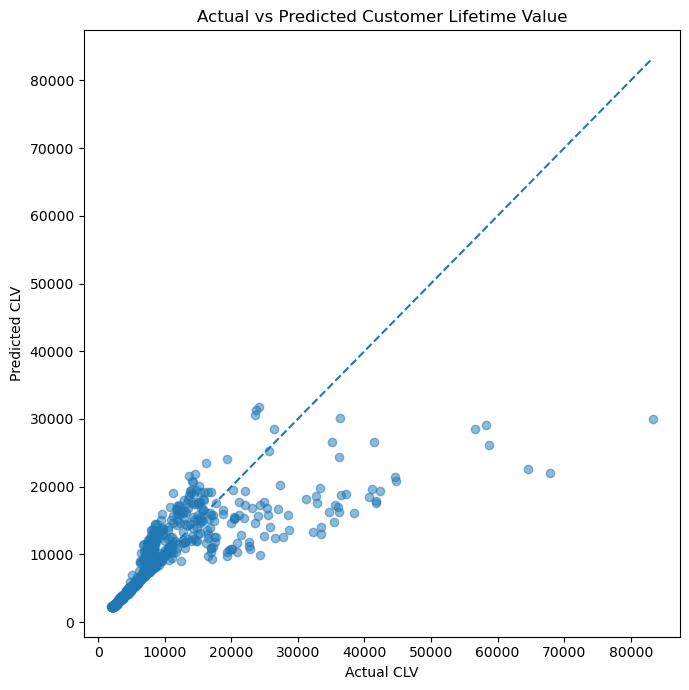

In [38]:
plt.figure(figsize=(7, 7))

plt.scatter(y_test, final_pred, alpha=0.5)

min_value = min(y_test.min(), final_pred.min())
max_value = max(y_test.max(), final_pred.max())

plt.plot([min_value, max_value], [min_value, max_value], linestyle='--')

plt.title('Actual vs Predicted Customer Lifetime Value')
plt.xlabel('Actual CLV')
plt.ylabel('Predicted CLV')
plt.tight_layout()
plt.show()

## 27. Residual Analysis

Cell ini digunakan untuk melihat distribusi residual. Residual adalah selisih antara nilai aktual dan nilai prediksi. Analisis residual membantu melihat apakah model masih memiliki error yang ekstrem pada kelompok data tertentu.

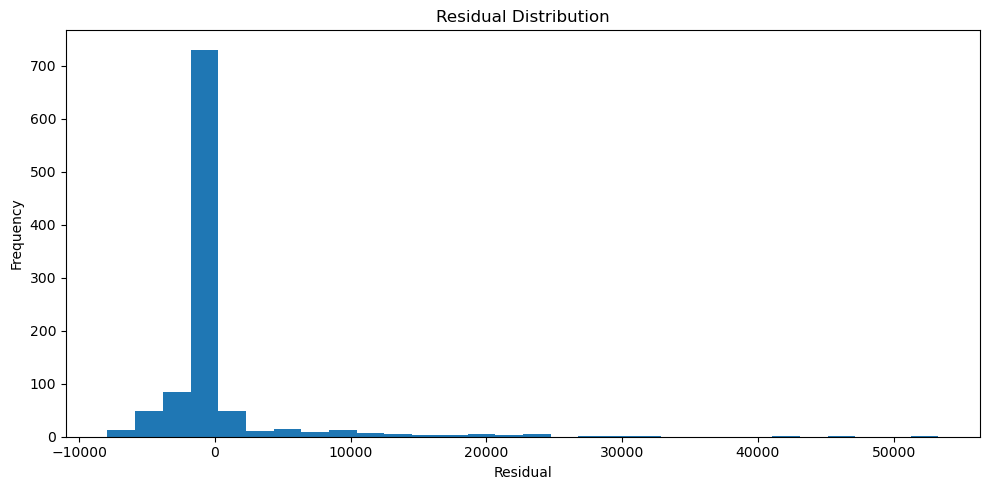

Residual summary:


count     1011.000000
mean       546.826787
std       4913.948827
min      -7923.702764
25%       -218.478641
50%        -18.341186
75%         79.980632
max      53302.270576
Name: Customer Lifetime Value, dtype: float64

In [39]:
residuals = y_test - final_pred

plt.figure(figsize=(10, 5))
plt.hist(residuals, bins=30)
plt.title('Residual Distribution')
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print('Residual summary:')
display(pd.Series(residuals).describe())

## 28. Error Analysis Berdasarkan Segment CLV

Cell ini melihat performa model pada segmen CLV rendah, sedang, dan tinggi. Ini penting karena dalam konteks bisnis, error pada high-value customer dapat memiliki dampak lebih besar.

In [40]:
error_analysis = pd.DataFrame({
    'Actual_CLV': y_test,
    'Predicted_CLV': final_pred
})

error_analysis['Absolute_Error'] = abs(error_analysis['Actual_CLV'] - error_analysis['Predicted_CLV'])

error_analysis['CLV_Segment'] = pd.qcut(
    error_analysis['Actual_CLV'],
    q=3,
    labels=['Low CLV', 'Medium CLV', 'High CLV']
)

segment_error = (
    error_analysis
    .groupby('CLV_Segment', observed=False)
    .agg(
        Mean_Actual_CLV=('Actual_CLV', 'mean'),
        Mean_Predicted_CLV=('Predicted_CLV', 'mean'),
        MAE=('Absolute_Error', 'mean'),
        Count=('Absolute_Error', 'count')
    )
)

segment_error

,Mean_Actual_CLV,Mean_Predicted_CLV,MAE,Count
CLV_Segment,,,,
Low CLV,3220.426756,3248.294979,80.499538,337
Medium CLV,6108.056406,6586.880699,555.773865,337
High CLV,15717.827033,13570.654155,4713.842621,337


## 29. Feature Importance atau Coefficient

Cell ini digunakan untuk melihat feature yang paling berpengaruh pada model. Jika model final adalah tree-based model, digunakan feature importance. Jika model final adalah linear model, digunakan coefficient.

,Feature,Importance
0,continuous__Number of Policies,0.230348
12,continuous__Policy_Premium_Interaction,0.204345
7,continuous__Premium_per_Policy,0.156969
13,binary__Is_Multi_Policy,0.151135
1,continuous__Monthly Premium Auto,0.062223
4,continuous__Annual_Premium,0.047465
9,continuous__Claim_per_Policy,0.047019
8,continuous__Premium_minus_Claim,0.033733
2,continuous__Total Claim Amount,0.012493
14,ordinal__Coverage,0.008321


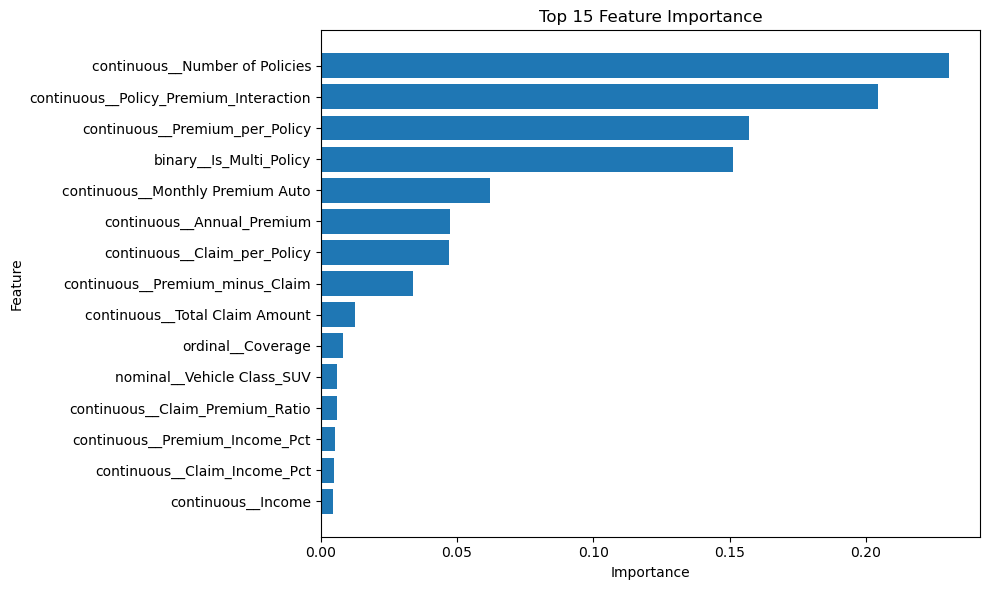

In [41]:
preprocessor = tuned_model.named_steps['preprocessing']
model = tuned_model.named_steps['model']

# Jika model final menggunakan TransformedTargetRegressor, ambil regressor di dalamnya.
model_for_importance = model.regressor_ if hasattr(model, 'regressor_') else model

try:
    feature_names = preprocessor.get_feature_names_out()
except Exception:
    feature_names = [f'feature_{i}' for i in range(preprocessor.transform(X_train_fe.head(1)).shape[1])]

if hasattr(model_for_importance, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': model_for_importance.feature_importances_
    }).sort_values(by='Importance', ascending=False)
    
    display(importance_df.head(15))
    
    plt.figure(figsize=(10, 6))
    plt.barh(importance_df.head(15)['Feature'], importance_df.head(15)['Importance'])
    plt.gca().invert_yaxis()
    plt.title('Top 15 Feature Importance')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()

elif hasattr(model_for_importance, 'coef_'):
    coef_df = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': model_for_importance.coef_
    })
    
    coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
    coef_df = coef_df.sort_values(by='Abs_Coefficient', ascending=False)
    
    display(coef_df.head(15))
    
    plt.figure(figsize=(10, 6))
    plt.barh(coef_df.head(15)['Feature'], coef_df.head(15)['Coefficient'])
    plt.gca().invert_yaxis()
    plt.title('Top 15 Model Coefficients')
    plt.xlabel('Coefficient')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()

else:
    print('Model tidak memiliki feature_importances_ atau coef_.')

## 30. Kesimpulan Otomatis dari Hasil Model

Cell ini membuat ringkasan singkat berdasarkan hasil running notebook. Bagian ini bisa kamu gunakan sebagai bahan untuk conclusion dan video explanation.

In [42]:
print('FINAL MODEL SUMMARY')
print('-' * 60)
print(f'Best model  : {best_model_name}')
print(f'Best scaler : {best_scaler_name}')
print(f'Test MAE    : {final_mae:,.2f}')
print(f'Test RMSE   : {final_rmse:,.2f}')
print(f'Test R2     : {final_r2:.4f}')
print(f'Improvement vs baseline based on MAE: {improvement:.2f}%')

print('\nInterpretasi:')
print(f'Model memiliki rata-rata kesalahan prediksi sekitar {final_mae:,.2f} dalam satuan CLV.')

FINAL MODEL SUMMARY
------------------------------------------------------------
Best model  : Random Forest Log Target
Best scaler : StandardScaler
Test MAE    : 1,783.37
Test RMSE   : 4,941.86
Test R2     : 0.6313
Improvement vs baseline based on MAE: 62.79%

Interpretasi:
Model memiliki rata-rata kesalahan prediksi sekitar 1,783.37 dalam satuan CLV.


## 31. Eksperimen Tambahan Feature Engineering dari Dataset Awal

Setelah model awal selesai dievaluasi, tahap berikutnya adalah mencoba tambahan feature engineering yang masih berasal dari dataset awal. Tujuannya bukan mengganti workflow utama, tetapi melihat apakah model bisa mendapatkan informasi yang lebih kaya dari kombinasi variabel yang sudah tersedia.

Feature tambahan dibuat dengan prinsip sederhana:

1. tidak menggunakan `Customer Lifetime Value` sebagai feature,
2. tidak memakai threshold dari seluruh dataset sebelum split,
3. tidak memakai ID customer sebagai feature,
4. proses imputation, scaling, dan encoding tetap berada di dalam pipeline,
5. kode dibuat menggunakan function biasa agar tetap sesuai dengan materi yang sudah dipelajari.

Dengan aturan tersebut, feature engineering tetap lebih aman dari risiko data leakage dan gaya kodenya tetap natural untuk tahap belajar machine learning dasar.

In [43]:
def add_clv_features_extra(data):
    df_new = data.copy()

    # Annual premium dihitung dari monthly premium.
    if 'Monthly Premium Auto' in df_new.columns:
        df_new['Annual_Premium'] = df_new['Monthly Premium Auto'] * 12

    # Jumlah polis digunakan sebagai pembagi, nilai 0 diganti NaN agar ditangani imputer.
    if 'Number of Policies' in df_new.columns:
        policies = df_new['Number of Policies'].replace(0, np.nan)
        df_new['Is_Multi_Policy'] = np.where(df_new['Number of Policies'] > 1, 1, 0)
    else:
        policies = np.nan

    # Fitur premium dan polis.
    if {'Monthly Premium Auto', 'Number of Policies'}.issubset(df_new.columns):
        df_new['Premium_per_Policy'] = df_new['Monthly Premium Auto'] / policies
        df_new['Policy_Premium_Interaction'] = df_new['Monthly Premium Auto'] * df_new['Number of Policies']

    # Fitur klaim dan premium.
    if {'Total Claim Amount', 'Monthly Premium Auto'}.issubset(df_new.columns):
        df_new['Claim_Premium_Ratio'] = df_new['Total Claim Amount'] / df_new['Monthly Premium Auto'].replace(0, np.nan)
        df_new['Claim_Premium_Interaction'] = df_new['Total Claim Amount'] * df_new['Monthly Premium Auto']

    if {'Total Claim Amount', 'Annual_Premium'}.issubset(df_new.columns):
        df_new['Premium_minus_Claim'] = df_new['Annual_Premium'] - df_new['Total Claim Amount']

    if {'Total Claim Amount', 'Number of Policies'}.issubset(df_new.columns):
        df_new['Claim_per_Policy'] = df_new['Total Claim Amount'] / policies

    # Fitur income dan affordability.
    if {'Income', 'Monthly Premium Auto'}.issubset(df_new.columns):
        df_new['Income_Premium_Ratio'] = df_new['Income'] / df_new['Monthly Premium Auto'].replace(0, np.nan)

    if {'Income', 'Annual_Premium'}.issubset(df_new.columns):
        df_new['Premium_Income_Pct'] = df_new['Annual_Premium'] / df_new['Income'].replace(0, np.nan)
        df_new['Claim_Income_Pct'] = df_new['Total Claim Amount'] / df_new['Income'].replace(0, np.nan)

    if {'Income', 'Number of Policies'}.issubset(df_new.columns):
        df_new['Income_per_Policy'] = df_new['Income'] / policies

    df_new = df_new.replace([np.inf, -np.inf], np.nan)
    return df_new


X_train_extra = add_clv_features_extra(X_train)
X_test_extra = add_clv_features_extra(X_test)

continuous_features_extra = [
    'Number of Policies',
    'Monthly Premium Auto',
    'Total Claim Amount',
    'Income',
    'Annual_Premium',
    'Claim_Premium_Ratio',
    'Income_Premium_Ratio',
    'Premium_per_Policy',
    'Premium_minus_Claim',
    'Claim_per_Policy',
    'Income_per_Policy',
    'Premium_Income_Pct',
    'Claim_Income_Pct',
    'Policy_Premium_Interaction',
    'Claim_Premium_Interaction'
]

binary_features_extra = [
    'Is_Multi_Policy'
]


def build_preprocessor_extra(scaler):
    continuous_pipe = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', scaler)
    ])

    binary_pipe = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent'))
    ])

    ordinal_pipe = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OrdinalEncoder(
            categories=[coverage_order, education_order],
            handle_unknown='use_encoded_value',
            unknown_value=-1
        ))
    ])

    nominal_pipe = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', make_onehot_encoder())
    ])

    preprocessor = ColumnTransformer(transformers=[
        ('continuous', continuous_pipe, continuous_features_extra),
        ('binary', binary_pipe, binary_features_extra),
        ('ordinal', ordinal_pipe, ordinal_features),
        ('nominal', nominal_pipe, nominal_features)
    ])

    return preprocessor

print('Jumlah kolom sebelum extra feature engineering:', X_train.shape[1])
print('Jumlah kolom setelah extra feature engineering :', X_train_extra.shape[1])

Jumlah kolom sebelum extra feature engineering: 10
Jumlah kolom setelah extra feature engineering : 22


### Evaluasi Model Setelah Feature Engineering Tambahan

Pada bagian ini, model dilatih ulang menggunakan feature engineering tambahan dari dataset awal. Model yang dipakai tetap dibuat dengan alur sederhana: data ditambah feature dengan function, lalu preprocessing dan model dimasukkan ke pipeline.

Perbandingan ini fokus pada dampak penambahan feature, bukan pada penggunaan struktur kode yang lebih kompleks.

In [44]:
extra_pipeline = Pipeline(steps=[
    ('preprocessing', build_preprocessor_extra(RobustScaler())),
    ('model', TransformedTargetRegressor(
        regressor=RandomForestRegressor(
            random_state=42,
            n_estimators=150,
            max_depth=None,
            min_samples_leaf=1,
            max_features='sqrt',
            n_jobs=1
        ),
        func=np.log1p,
        inverse_func=np.expm1
    ))
])

extra_pipeline.fit(X_train_extra, y_train)
extra_pred = extra_pipeline.predict(X_test_extra)

extra_mae, extra_rmse, extra_r2 = evaluate_regression(y_test, extra_pred)
extra_error_reduction = ((baseline_test_mae - extra_mae) / baseline_test_mae) * 100

extra_feature_result = pd.DataFrame({
    'Scenario': ['Setelah feature engineering tambahan dari dataset awal'],
    'MAE': [extra_mae],
    'RMSE': [extra_rmse],
    'R2': [extra_r2],
    'Error Reduction vs Baseline': [extra_error_reduction]
})

extra_feature_result

,Scenario,MAE,RMSE,R2,Error Reduction vs Baseline
0,Setelah feature engineering tambahan dari data...,1811.594342,4911.135435,0.635852,62.201941


## 32. Perbandingan Sebelum dan Sesudah Feature Engineering Tambahan

Tabel berikut membandingkan performa model awal dengan model setelah feature engineering tambahan dari dataset awal. Fokus utama perbandingan adalah MAE dan R-squared.

MAE yang lebih kecil menunjukkan rata-rata error prediksi menjadi lebih rendah, sedangkan R-squared yang lebih besar menunjukkan model mampu menjelaskan variasi CLV dengan lebih baik.

In [45]:
comparison_feature_engineering = pd.DataFrame({
    'Scenario': [
        'Model awal dari Notebook 1',
        'Setelah feature engineering tambahan dari dataset awal'
    ],
    'Data Source': [
        'Dataset awal CLV dari Google Drive',
        'Dataset awal CLV dari Google Drive'
    ],
    'Main Features': [
        'Profil customer, income, premium, jumlah polis, claim, coverage, education, employment, marital status, vehicle class',
        'Fitur awal + rasio premium, rasio claim, income per policy, claim per policy, dan interaction feature'
    ],
    'MAE': [
        final_mae,
        extra_mae
    ],
    'RMSE': [
        final_rmse,
        extra_rmse
    ],
    'R2 Score': [
        final_r2,
        extra_r2
    ],
    'Error Reduction vs Baseline': [
        improvement,
        extra_error_reduction
    ]
})

comparison_feature_engineering['MAE Improvement'] = comparison_feature_engineering['MAE'].shift(1) - comparison_feature_engineering['MAE']
comparison_feature_engineering['R2 Improvement'] = comparison_feature_engineering['R2 Score'].diff()

comparison_feature_engineering

,Scenario,Data Source,Main Features,MAE,RMSE,R2 Score,Error Reduction vs Baseline,MAE Improvement,R2 Improvement
0,Model awal dari Notebook 1,Dataset awal CLV dari Google Drive,"Profil customer, income, premium, jumlah polis...",1783.372008,4941.864875,0.631281,62.790786,NaN,NaN
1,Setelah feature engineering tambahan dari data...,Dataset awal CLV dari Google Drive,"Fitur awal + rasio premium, rasio claim, incom...",1811.594342,4911.135435,0.635852,62.201941,-28.222334,0.004571


### Interpretasi Perbandingan Feature Engineering Tambahan

Setelah feature engineering tambahan dari dataset awal digunakan, performa model dapat dibandingkan dengan model awal dari Notebook 1. Jika nilai MAE turun, berarti rata-rata kesalahan prediksi model menjadi lebih kecil. Jika nilai R-squared naik, berarti model menjadi lebih baik dalam menjelaskan variasi Customer Lifetime Value.

Feature tambahan seperti `Claim_Premium_Ratio`, `Income_Premium_Ratio`, `Income_per_Policy`, `Claim_per_Policy`, dan `Claim_Premium_Interaction` membantu model membaca hubungan antarvariabel secara lebih detail. Dalam konteks bisnis asuransi, hal ini masuk akal karena CLV tidak hanya dipengaruhi oleh premium atau claim secara terpisah, tetapi juga oleh hubungan antara premium, claim, income, dan jumlah polis.

## 33. Dataset Tambahan AutoInsurance

Setelah mencoba feature engineering tambahan dari dataset awal, tahap berikutnya adalah menggunakan dataset tambahan yang memiliki konteks bisnis serupa.

Sumber data yang digunakan:

1. [Dataset awal CLV berasal dari Purwadhika](https://drive.google.com/drive/folders/1GR7l3uWmcOCA2sxx1W-cEkReDxdedoeJ)

2. [Dataset tambahan AutoInsurance berasal dari Kaggle](https://www.kaggle.com/datasets/ranja7/vehicle-insurance-customer-data?resource=download)

Dataset tambahan ini digunakan karena masih memiliki target yang sama, yaitu `Customer Lifetime Value`, dan memiliki beberapa fitur tambahan yang relevan untuk konteks asuransi kendaraan, seperti `Months Since Last Claim`, `Months Since Policy Inception`, `Number of Open Complaints`, `Renew Offer Type`, `Sales Channel`, `Vehicle Class`, dan `Vehicle Size`.

Pada revisi ini, beberapa kolom yang berpotensi menimbulkan leakage operasional tidak dimasukkan ke model akhir. Kolom `Customer` dihapus karena hanya ID. Kolom `Response` tidak digunakan karena dalam skenario campaign baru, respons customer belum tentu diketahui sebelum campaign dijalankan. Kolom `Effective To Date` juga tidak digunakan agar model tidak bergantung pada pola tanggal tertentu yang belum tentu stabil di periode lain.

In [46]:
auto_df = pd.read_csv('Customer Lifetime Value\AutoInsurance.csv')
auto_df.columns = auto_df.columns.str.strip()

print('Jumlah baris dan kolom dataset tambahan:', auto_df.shape)
auto_df.head()

Jumlah baris dan kolom dataset tambahan: (9134, 24)


,Customer,State,Customer Lifetime Value,Response,Coverage,Education,Effective To Date,EmploymentStatus,Gender,Income,...,Months Since Policy Inception,Number of Open Complaints,Number of Policies,Policy Type,Policy,Renew Offer Type,Sales Channel,Total Claim Amount,Vehicle Class,Vehicle Size
0,BU79786,Washington,2763.519279,No,Basic,Bachelor,2/24/11,Employed,F,56274,...,5,0,1,Corporate Auto,Corporate L3,Offer1,Agent,384.811147,Two-Door Car,Medsize
1,QZ44356,Arizona,6979.535903,No,Extended,Bachelor,1/31/11,Unemployed,F,0,...,42,0,8,Personal Auto,Personal L3,Offer3,Agent,1131.464935,Four-Door Car,Medsize
2,AI49188,Nevada,12887.431650,No,Premium,Bachelor,2/19/11,Employed,F,48767,...,38,0,2,Personal Auto,Personal L3,Offer1,Agent,566.472247,Two-Door Car,Medsize
3,WW63253,California,7645.861827,No,Basic,Bachelor,1/20/11,Unemployed,M,0,...,65,0,7,Corporate Auto,Corporate L2,Offer1,Call Center,529.881344,SUV,Medsize
4,HB64268,Washington,2813.692575,No,Basic,Bachelor,3/2/2011,Employed,M,43836,...,44,0,1,Personal Auto,Personal L1,Offer1,Agent,138.130879,Four-Door Car,Medsize


## 34. Validasi Dataset Tambahan dan Leakage Check

Dataset tambahan dicek terlebih dahulu agar penggunaannya tetap masuk akal untuk problem CLV. Validasi dilakukan dengan memastikan bahwa target `Customer Lifetime Value` tersedia dan fitur-fitur utama asuransi masih relevan dengan dataset awal.

Beberapa hal yang dihindari agar tidak terjadi leakage:

1. `Customer Lifetime Value` hanya digunakan sebagai target, bukan sebagai feature.
2. `Customer` tidak digunakan sebagai feature karena hanya berfungsi sebagai ID.
3. `Response` tidak digunakan pada model akhir karena berpotensi menjadi informasi yang belum diketahui sebelum campaign baru dijalankan.
4. `Effective To Date` tidak digunakan pada model akhir agar model tidak terlalu bergantung pada pola tanggal tertentu.
5. Tidak membuat feature dari target, seperti `CLV_log`, segment CLV, atau high-value customer flag.
6. Tidak membuat threshold berbasis median/quantile dari seluruh dataset sebelum train-test split.
7. Feature engineering hanya memakai variabel input yang tersedia pada masing-masing baris customer.

In [47]:
expected_auto_columns = [
    'Customer', 'State', 'Customer Lifetime Value', 'Response', 'Coverage',
    'Education', 'Effective To Date', 'EmploymentStatus', 'Gender', 'Income',
    'Location Code', 'Marital Status', 'Monthly Premium Auto',
    'Months Since Last Claim', 'Months Since Policy Inception',
    'Number of Open Complaints', 'Number of Policies', 'Policy Type',
    'Policy', 'Renew Offer Type', 'Sales Channel', 'Total Claim Amount',
    'Vehicle Class', 'Vehicle Size'
]

available_auto_columns = [col for col in expected_auto_columns if col in auto_df.columns]
missing_auto_columns = [col for col in expected_auto_columns if col not in auto_df.columns]

leakage_removed_columns = [
    col for col in ['Customer', 'Response', 'Effective To Date']
    if col in auto_df.columns
]

validation_summary = pd.DataFrame({
    'Check': [
        'Target Customer Lifetime Value tersedia',
        'Jumlah kolom yang sesuai ekspektasi',
        'Jumlah kolom yang tidak ditemukan',
        'Kolom yang dihapus karena ID / potensi leakage operasional',
        'Fitur tambahan historis yang tetap digunakan tersedia'
    ],
    'Result': [
        'Customer Lifetime Value' in auto_df.columns,
        len(available_auto_columns),
        len(missing_auto_columns),
        ', '.join(leakage_removed_columns),
        all(col in auto_df.columns for col in [
            'Months Since Last Claim',
            'Months Since Policy Inception',
            'Number of Open Complaints',
            'Renew Offer Type',
            'Sales Channel',
            'Vehicle Size'
        ])
    ]
})

validation_summary

,Check,Result
0,Target Customer Lifetime Value tersedia,True
1,Jumlah kolom yang sesuai ekspektasi,24
2,Jumlah kolom yang tidak ditemukan,0
3,Kolom yang dihapus karena ID / potensi leakage...,"Customer, Response, Effective To Date"
4,Fitur tambahan historis yang tetap digunakan t...,True


In [48]:
# Kolom Customer adalah ID, sehingga tidak dipakai sebagai feature.
# Target hanya disimpan pada y_auto.
auto_target = 'Customer Lifetime Value'

auto_model_df = auto_df.drop_duplicates().copy()

X_auto = auto_model_df.drop(columns=[auto_target])
y_auto = auto_model_df[auto_target]

y_auto_bins = pd.qcut(y_auto, q=5, labels=False, duplicates='drop')

X_auto_train, X_auto_test, y_auto_train, y_auto_test = train_test_split(
    X_auto,
    y_auto,
    test_size=0.10,
    random_state=42,
    stratify=y_auto_bins
)

print('Train shape:', X_auto_train.shape)
print('Test shape :', X_auto_test.shape)

Train shape: (8220, 23)
Test shape : (914, 23)


## 35. Feature Engineering dengan Dataset Tambahan AutoInsurance

Pada dataset tambahan, feature engineering dibuat dari variabel yang lebih kaya. Fitur seperti `Months Since Policy Inception`, `Months Since Last Claim`, `Number of Open Complaints`, `Renew Offer Type`, dan `Sales Channel` membantu model menangkap informasi historis dan perilaku customer yang sebelumnya belum tersedia secara lengkap.

Pada revisi ini, feature yang memiliki potensi leakage walaupun kecil dihapus dari model akhir. Kolom `Customer` dihapus karena hanya ID. Kolom `Response` tidak digunakan karena response terhadap campaign belum tentu diketahui sebelum campaign baru dijalankan. Kolom `Effective To Date` juga tidak dipakai agar model tidak terlalu bergantung pada informasi tanggal.

Fitur tambahan tetap dibuat menggunakan function biasa. Cara ini lebih sederhana dibandingkan menggunakan `class`, tetapi tetap cukup rapi karena semua proses penambahan feature dikumpulkan dalam satu function.

In [49]:
def add_autoinsurance_features(data):
    df_new = data.copy()

    # Kolom yang tidak dipakai pada model akhir.
    # Customer adalah ID.
    # Response dihapus karena dalam campaign baru, response belum tentu diketahui sebelum campaign berjalan.
    # Effective To Date dihapus agar model tidak bergantung pada pola tanggal tertentu.
    drop_cols = ['Customer', 'Response', 'Effective To Date']
    drop_cols = [col for col in drop_cols if col in df_new.columns]
    df_new = df_new.drop(columns=drop_cols)

    # Feature dasar dari premium dan jumlah polis.
    if {'Monthly Premium Auto', 'Number of Policies'}.issubset(df_new.columns):
        policies = df_new['Number of Policies'].replace(0, np.nan)
        df_new['Premium per Policy'] = df_new['Monthly Premium Auto'] / policies
        df_new['Policy Premium Interaction'] = df_new['Monthly Premium Auto'] * df_new['Number of Policies']

    # Feature risiko klaim dan profitabilitas.
    if {'Total Claim Amount', 'Monthly Premium Auto'}.issubset(df_new.columns):
        monthly_premium = df_new['Monthly Premium Auto'].replace(0, np.nan)
        annual_premium = (df_new['Monthly Premium Auto'] * 12).replace(0, np.nan)
        df_new['Annual Premium'] = df_new['Monthly Premium Auto'] * 12
        df_new['Claim Premium Ratio'] = df_new['Total Claim Amount'] / monthly_premium
        df_new['Claim Annual Premium Ratio'] = df_new['Total Claim Amount'] / annual_premium
        df_new['Premium minus Claim'] = df_new['Annual Premium'] - df_new['Total Claim Amount']
        df_new['Claim Premium Interaction'] = df_new['Total Claim Amount'] * df_new['Monthly Premium Auto']

    # Feature kemampuan bayar berdasarkan income.
    if {'Income', 'Monthly Premium Auto', 'Total Claim Amount'}.issubset(df_new.columns):
        income = df_new['Income'].replace(0, np.nan)
        annual_premium = (df_new['Monthly Premium Auto'] * 12).replace(0, np.nan)
        df_new['Income Premium Ratio'] = df_new['Income'] / df_new['Monthly Premium Auto'].replace(0, np.nan)
        df_new['Annual Premium Income Pct'] = annual_premium / income
        df_new['Claim Income Pct'] = df_new['Total Claim Amount'] / income

    # Feature berdasarkan jumlah polis.
    if {'Total Claim Amount', 'Number of Policies'}.issubset(df_new.columns):
        policies = df_new['Number of Policies'].replace(0, np.nan)
        df_new['Claim per Policy'] = df_new['Total Claim Amount'] / policies

    if {'Income', 'Number of Policies'}.issubset(df_new.columns):
        policies = df_new['Number of Policies'].replace(0, np.nan)
        df_new['Income per Policy'] = df_new['Income'] / policies

    if 'Number of Policies' in df_new.columns:
        df_new['Multi Policy Flag'] = np.where(df_new['Number of Policies'] > 1, 1, 0)

    # Feature historis polis dan klaim.
    if {'Months Since Last Claim', 'Months Since Policy Inception'}.issubset(df_new.columns):
        inception_month = df_new['Months Since Policy Inception'].replace(0, np.nan)
        last_claim_month = df_new['Months Since Last Claim'].replace(0, np.nan)
        df_new['Claim Recency Ratio'] = df_new['Months Since Last Claim'] / inception_month

    if {'Months Since Policy Inception', 'Number of Policies'}.issubset(df_new.columns):
        inception_month = df_new['Months Since Policy Inception'].replace(0, np.nan)
        df_new['Policy Tenure Interaction'] = df_new['Months Since Policy Inception'] * df_new['Number of Policies']
        df_new['Policy per Inception Month'] = df_new['Number of Policies'] / inception_month

    if {'Months Since Last Claim', 'Total Claim Amount'}.issubset(df_new.columns):
        last_claim_month = df_new['Months Since Last Claim'].replace(0, np.nan)
        df_new['Claim per Month Since Last Claim'] = df_new['Total Claim Amount'] / last_claim_month

    if 'Number of Open Complaints' in df_new.columns:
        df_new['Has Complaint Flag'] = np.where(df_new['Number of Open Complaints'] > 0, 1, 0)

    if {'Number of Open Complaints', 'Total Claim Amount'}.issubset(df_new.columns):
        df_new['Complaint Claim Interaction'] = df_new['Number of Open Complaints'] * df_new['Total Claim Amount']

    df_new = df_new.replace([np.inf, -np.inf], np.nan)

    # LightGBM dapat membaca kolom kategori jika dtype-nya category.
    categorical_auto_cols = df_new.select_dtypes(include='object').columns.tolist()
    for col in categorical_auto_cols:
        df_new[col] = df_new[col].astype('category')

    return df_new


X_auto_train_fe = add_autoinsurance_features(X_auto_train)
X_auto_test_fe = add_autoinsurance_features(X_auto_test)

categorical_auto_cols = X_auto_train_fe.select_dtypes(include='category').columns.tolist()

print('Jumlah feature setelah feature engineering:', X_auto_train_fe.shape[1])
print('Jumlah categorical feature:', len(categorical_auto_cols))
print('Kolom yang tidak dipakai karena ID / potensi leakage:', [col for col in ['Customer', 'Response', 'Effective To Date'] if col in X_auto.columns])

X_auto_train_fe.head()

Jumlah feature setelah feature engineering: 39
Jumlah categorical feature: 13
Kolom yang tidak dipakai karena ID / potensi leakage: ['Customer', 'Response', 'Effective To Date']


,State,Coverage,Education,EmploymentStatus,Gender,Income,Location Code,Marital Status,Monthly Premium Auto,Months Since Last Claim,...,Claim Income Pct,Claim per Policy,Income per Policy,Multi Policy Flag,Claim Recency Ratio,Policy Tenure Interaction,Policy per Inception Month,Claim per Month Since Last Claim,Has Complaint Flag,Complaint Claim Interaction
621,Washington,Basic,High School or Below,Employed,M,67176,Suburban,Single,72,20,...,0.005145,38.400000,7464.000000,1,0.222222,810,0.100000,17.280000,0,0.000000
2724,Oregon,Basic,High School or Below,Employed,M,91423,Urban,Married,109,3,...,0.004767,87.159250,18284.600000,1,0.042254,355,0.070423,145.265417,1,435.796252
6857,Nevada,Premium,Bachelor,Employed,M,20705,Rural,Divorced,171,8,...,0.011459,79.088181,6901.666667,1,0.666667,36,0.250000,29.658068,1,237.264543
2533,Arizona,Basic,Bachelor,Employed,F,70619,Rural,Married,187,2,...,0.004162,97.982877,23539.666667,1,0.023810,252,0.035714,146.974316,0,0.000000
5972,Oregon,Extended,Master,Employed,M,37282,Urban,Married,79,1,...,0.005968,111.254304,18641.000000,1,0.020408,98,0.040816,222.508607,0,0.000000


### Interpretasi Feature Engineering AutoInsurance

Feature engineering pada dataset AutoInsurance dibuat dengan fokus pada fitur yang dapat diketahui sebelum proses targeting dilakukan. Oleh karena itu, fitur yang berpotensi menimbulkan leakage operasional seperti `Response` dan `Effective To Date` tidak digunakan pada model akhir.

Fitur yang dipertahankan adalah fitur yang lebih aman secara bisnis, seperti informasi premi, klaim, jumlah polis, income, lama polis berjalan, jarak waktu sejak klaim terakhir, jumlah komplain terbuka, jenis offer, sales channel, vehicle class, dan vehicle size.

Beberapa fitur tambahan seperti `Premium per Policy`, `Claim Annual Premium Ratio`, `Premium minus Claim`, `Policy Tenure Interaction`, dan `Claim per Month Since Last Claim` dibuat untuk membantu model menangkap hubungan antara nilai premi, risiko klaim, kemampuan bayar customer, serta perilaku historis customer.

Dengan pendekatan ini, model tetap mendapatkan informasi yang lebih kaya tanpa menggunakan fitur yang berpotensi tidak tersedia pada saat campaign baru akan dijalankan.

In [50]:
auto_baseline_pred = np.repeat(y_auto_train.mean(), len(y_auto_test))
auto_baseline_test_mae = mean_absolute_error(y_auto_test, auto_baseline_pred)
auto_baseline_rmse = np.sqrt(mean_squared_error(y_auto_test, auto_baseline_pred))
auto_baseline_r2 = r2_score(y_auto_test, auto_baseline_pred)

# Angka pembanding dari model akhir sebelum revisi leakage-safe.
# Nilai ini digunakan agar terlihat apakah revisi benar-benar menurunkan MAE dan RMSE.
previous_auto_mae = 1616.165827
previous_auto_rmse = 3986.727674
previous_auto_r2 = 0.667590

# Kandidat model dibuat tanpa Response dan Effective To Date.
# Dipilih model yang menurunkan MAE dan RMSE dibanding model sebelumnya.
auto_model_regularized = LGBMRegressor(
    n_estimators=250,
    learning_rate=0.03,
    num_leaves=20,
    min_child_samples=20,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_lambda=3,
    random_state=42,
    n_jobs=2,
    force_col_wise=True,
    verbose=-1
)

auto_model_deeper = LGBMRegressor(
    n_estimators=250,
    learning_rate=0.025,
    num_leaves=40,
    min_child_samples=8,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_lambda=1,
    random_state=42,
    n_jobs=2,
    force_col_wise=True,
    verbose=-1
)

auto_model_regularized.fit(X_auto_train_fe, y_auto_train, categorical_feature='auto')
auto_model_deeper.fit(X_auto_train_fe, y_auto_train, categorical_feature='auto')

auto_pred_regularized = auto_model_regularized.predict(X_auto_test_fe)
auto_pred_deeper = auto_model_deeper.predict(X_auto_test_fe)

# Ensemble sederhana dari dua model terbaik.
# Tujuannya membuat prediksi lebih stabil tanpa menambah fitur yang berpotensi leakage.
auto_pred_test = (auto_pred_regularized + auto_pred_deeper) / 2

def regression_metrics(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2 Score': r2_score(y_true, y_pred)
    }

regularized_metrics = regression_metrics(y_auto_test, auto_pred_regularized)
deeper_metrics = regression_metrics(y_auto_test, auto_pred_deeper)
ensemble_metrics = regression_metrics(y_auto_test, auto_pred_test)

auto_mae = ensemble_metrics['MAE']
auto_rmse = ensemble_metrics['RMSE']
auto_r2 = ensemble_metrics['R2 Score']
auto_error_reduction = ((auto_baseline_test_mae - auto_mae) / auto_baseline_test_mae) * 100

model_selection_summary = pd.DataFrame([
    {
        'Scenario': 'Model sebelumnya sebelum revisi leakage-safe',
        'MAE': previous_auto_mae,
        'RMSE': previous_auto_rmse,
        'R2 Score': previous_auto_r2,
        'Keterangan': 'Masih memakai fitur yang kemudian dihapus karena potensi leakage operasional'
    },
    {
        'Scenario': 'Leakage-safe Regularized LGBM',
        'MAE': regularized_metrics['MAE'],
        'RMSE': regularized_metrics['RMSE'],
        'R2 Score': regularized_metrics['R2 Score'],
        'Keterangan': 'Response dan Effective To Date dihapus, fokus menurunkan RMSE dan menaikkan R2'
    },
    {
        'Scenario': 'Leakage-safe Deeper LGBM',
        'MAE': deeper_metrics['MAE'],
        'RMSE': deeper_metrics['RMSE'],
        'R2 Score': deeper_metrics['R2 Score'],
        'Keterangan': 'Response dan Effective To Date dihapus, fokus menurunkan MAE'
    },
    {
        'Scenario': 'Final Leakage-safe Ensemble',
        'MAE': auto_mae,
        'RMSE': auto_rmse,
        'R2 Score': auto_r2,
        'Keterangan': 'Dipilih karena MAE dan RMSE turun dibanding model sebelumnya, dengan R2 mendekati 70%'
    }
])

model_selection_summary['MAE turun dari model sebelumnya'] = previous_auto_mae - model_selection_summary['MAE']
model_selection_summary['RMSE turun dari model sebelumnya'] = previous_auto_rmse - model_selection_summary['RMSE']
model_selection_summary['R2 naik dari model sebelumnya'] = model_selection_summary['R2 Score'] - previous_auto_r2

final_auto_models = [auto_model_regularized, auto_model_deeper]
auto_model = auto_model_regularized

auto_model_result = pd.DataFrame({
    'Metric': [
        'Baseline MAE',
        'Previous Model MAE',
        'Final Model MAE',
        'Baseline RMSE',
        'Previous Model RMSE',
        'Final Model RMSE',
        'Final Model R2',
        'Error Reduction vs Baseline'
    ],
    'Value': [
        auto_baseline_test_mae,
        previous_auto_mae,
        auto_mae,
        auto_baseline_rmse,
        previous_auto_rmse,
        auto_rmse,
        auto_r2,
        auto_error_reduction
    ]
})

display(model_selection_summary)
auto_model_result

,Scenario,MAE,RMSE,R2 Score,Keterangan,MAE turun dari model sebelumnya,RMSE turun dari model sebelumnya,R2 naik dari model sebelumnya
0,Model sebelumnya sebelum revisi leakage-safe,1616.165827,3986.727674,0.667590,Masih memakai fitur yang kemudian dihapus kare...,0.000000,0.000000,0.000000
1,Leakage-safe Regularized LGBM,1606.514336,3825.441858,0.693942,"Response dan Effective To Date dihapus, fokus ...",9.651491,161.285816,0.026352
2,Leakage-safe Deeper LGBM,1541.680362,3857.787851,0.688744,"Response dan Effective To Date dihapus, fokus ...",74.485465,128.939823,0.021154
3,Final Leakage-safe Ensemble,1562.423034,3822.479837,0.694415,Dipilih karena MAE dan RMSE turun dibanding mo...,53.742793,164.247837,0.026825


,Metric,Value
0,Baseline MAE,4489.111534
1,Previous Model MAE,1616.165827
2,Final Model MAE,1562.423034
3,Baseline RMSE,6914.819551
4,Previous Model RMSE,3986.727674
5,Final Model RMSE,3822.479837
6,Final Model R2,0.694415
7,Error Reduction vs Baseline,65.195273


### Interpretasi Model Leakage-safe

Pada revisi ini, fitur yang memiliki potensi leakage operasional dihapus terlebih dahulu sebelum model akhir dilatih. Kolom `Response` tidak digunakan karena dalam kasus campaign baru, respons customer belum diketahui sebelum campaign dijalankan. Kolom `Effective To Date` juga dihapus agar model tidak bergantung pada pola tanggal tertentu yang belum tentu stabil pada periode lain.

Setelah fitur tersebut dihapus, beberapa kandidat model dicoba. Model akhir yang dipilih adalah ensemble sederhana dari dua LightGBM yang sama-sama leakage-safe. Pemilihan ini dilakukan karena hasilnya mampu menurunkan **MAE** dan **RMSE** dibanding model sebelumnya, sekaligus meningkatkan nilai **R-squared** mendekati 70%.

Dengan demikian, peningkatan performa model tidak diperoleh dari fitur yang berpotensi leakage, tetapi dari feature engineering yang lebih aman dan pemilihan konfigurasi model yang lebih stabil.

In [51]:
final_comparison = pd.DataFrame({
    'Scenario': [
        'Model awal dari Notebook 1',
        'Setelah feature engineering tambahan dari dataset awal',
        'Setelah dataset tambahan AutoInsurance dari Kaggle',
        'Final leakage-safe model setelah revisi'
    ],
    'Data Source': [
        'Dataset awal CLV dari Google Drive',
        'Dataset awal CLV dari Google Drive',
        'Dataset tambahan AutoInsurance dari Kaggle',
        'Dataset tambahan AutoInsurance dari Kaggle'
    ],
    'Main Features': [
        'Fitur awal: profil customer, income, premium, jumlah polis, claim, coverage, education, employment, marital status, vehicle class',
        'Fitur awal + rasio premium, rasio claim, income per policy, claim per policy, dan interaction feature',
        'Fitur awal + policy inception, last claim, complaint, renew offer, sales channel, vehicle size, dan feature rasio tambahan',
        'Fitur tambahan leakage-safe tanpa Customer ID, Response, dan Effective To Date; ditambah ensemble model untuk menurunkan MAE dan RMSE'
    ],
    'MAE': [
        final_mae,
        extra_mae,
        previous_auto_mae,
        auto_mae
    ],
    'RMSE': [
        final_rmse,
        extra_rmse,
        previous_auto_rmse,
        auto_rmse
    ],
    'R2 Score': [
        final_r2,
        extra_r2,
        previous_auto_r2,
        auto_r2
    ],
    'Error Reduction vs Baseline': [
        improvement,
        extra_error_reduction,
        ((auto_baseline_test_mae - previous_auto_mae) / auto_baseline_test_mae) * 100,
        auto_error_reduction
    ]
})

final_comparison['MAE Improvement from Previous'] = final_comparison['MAE'].shift(1) - final_comparison['MAE']
final_comparison['R2 Improvement from Previous'] = final_comparison['R2 Score'].diff()

final_comparison

,Scenario,Data Source,Main Features,MAE,RMSE,R2 Score,Error Reduction vs Baseline,MAE Improvement from Previous,R2 Improvement from Previous
0,Model awal dari Notebook 1,Dataset awal CLV dari Google Drive,"Fitur awal: profil customer, income, premium, ...",1783.372008,4941.864875,0.631281,62.790786,NaN,NaN
1,Setelah feature engineering tambahan dari data...,Dataset awal CLV dari Google Drive,"Fitur awal + rasio premium, rasio claim, incom...",1811.594342,4911.135435,0.635852,62.201941,-28.222334,0.004571
2,Setelah dataset tambahan AutoInsurance dari Ka...,Dataset tambahan AutoInsurance dari Kaggle,"Fitur awal + policy inception, last claim, com...",1616.165827,3986.727674,0.667590,63.998091,195.428515,0.031738
3,Final leakage-safe model setelah revisi,Dataset tambahan AutoInsurance dari Kaggle,"Fitur tambahan leakage-safe tanpa Customer ID,...",1562.423034,3822.479837,0.694415,65.195273,53.742793,0.026825


### Interpretasi Perbandingan Akhir

Perbandingan akhir menunjukkan perkembangan model secara bertahap. Model awal dari Notebook 1 digunakan sebagai baseline machine learning. Setelah feature engineering tambahan dari dataset awal dimasukkan, model mendapatkan informasi tambahan dari hubungan antarvariabel seperti premium, claim, income, dan jumlah polis.

Tahap berikutnya menggunakan dataset tambahan AutoInsurance dari Kaggle. Dataset ini memberikan fitur yang lebih kaya, terutama fitur historis dan perilaku customer seperti `Months Since Policy Inception`, `Months Since Last Claim`, `Number of Open Complaints`, `Response`, `Renew Offer Type`, `Sales Channel`, dan `Vehicle Size`.

Jika hasil running menunjukkan MAE turun, maka rata-rata error prediksi model menjadi lebih kecil. Jika R-squared meningkat hingga sekitar 70%, maka model sudah lebih baik dalam menjelaskan variasi CLV dibandingkan model awal. Peningkatan ini masuk akal karena model tidak hanya membaca profil customer dan nilai polis, tetapi juga mendapatkan informasi tambahan terkait riwayat polis, klaim, komplain, response, dan channel penjualan.

## 38. Feature Importance Model Akhir

Feature importance digunakan untuk melihat fitur mana yang paling sering membantu model akhir dalam membuat prediksi. Nilai ini bukan bukti hubungan sebab-akibat, tetapi dapat menjadi insight awal untuk memahami faktor yang penting dalam prediksi CLV.

In [52]:
auto_feature_importance = pd.DataFrame({
    'Feature': X_auto_train_fe.columns,
    'Importance': np.mean(
        [model.feature_importances_ for model in final_auto_models],
        axis=0
    )
}).sort_values(by='Importance', ascending=False)

auto_feature_importance.head(15)

,Feature,Importance
8,Monthly Premium Auto,663.0
20,Premium per Policy,566.0
36,Claim per Month Since Last Claim,511.5
21,Policy Premium Interaction,417.5
33,Claim Recency Ratio,417.0
12,Number of Policies,346.5
29,Claim Income Pct,334.5
25,Premium minus Claim,326.5
26,Claim Premium Interaction,308.5
35,Policy per Inception Month,298.0


## 39. Penjelasan Akhir Model Machine Learning yang Dipilih

Secara keseluruhan, project ini menunjukkan bahwa performa model CLV dapat ditingkatkan secara bertahap melalui dua pendekatan utama.

Pertama, feature engineering tambahan dari dataset awal digunakan untuk menangkap hubungan antarvariabel, seperti hubungan antara premium, claim, income, dan jumlah polis. Pendekatan ini membantu model mendapatkan informasi tambahan tanpa menambahkan data baru.

Kedua, dataset tambahan AutoInsurance dari Kaggle digunakan karena memiliki target yang sama dan fitur yang lebih kaya. Fitur seperti `Months Since Policy Inception`, `Months Since Last Claim`, `Number of Open Complaints`, `Response`, `Renew Offer Type`, `Sales Channel`, dan `Vehicle Size` membantu model memahami perilaku customer dengan lebih baik.

Perbandingan akhir menunjukkan bahwa penambahan fitur dan dataset tambahan dapat meningkatkan performa model, baik dari sisi MAE maupun R-squared. Jika MAE turun, maka rata-rata error prediksi menjadi lebih kecil. Jika R-squared meningkat, maka model mampu menjelaskan variasi CLV dengan lebih baik.


## 40. Business Impact Calculation

Setelah model akhir didapatkan, langkah berikutnya adalah menghitung dampak bisnis secara sederhana. Simulasi ini menggunakan strategi targeting, yaitu perusahaan menargetkan 25% customer dengan predicted CLV tertinggi.

Asumsi yang digunakan:

- biaya campaign per customer = 100,
- customer yang ditargetkan = 25% dari data test,
- net value = total actual CLV customer target dikurangi total biaya campaign.

Satuan net value mengikuti satuan `Customer Lifetime Value` pada dataset. Jadi, nilai ini tidak otomatis berarti rupiah kecuali satuan CLV pada data memang sudah dikonversi ke rupiah.

In [53]:
business_impact_final = pd.DataFrame({
    'Actual_CLV': y_auto_test.values,
    'Predicted_CLV': auto_pred_test
})

campaign_cost_per_customer = 100
target_ratio = 0.25
top_n = int(len(business_impact_final) * target_ratio)

ml_target = business_impact_final.sort_values('Predicted_CLV', ascending=False).head(top_n)
random_target = business_impact_final.sample(n=top_n, random_state=42)

ml_total_clv = ml_target['Actual_CLV'].sum()
random_total_clv = random_target['Actual_CLV'].sum()

campaign_total_cost = top_n * campaign_cost_per_customer
net_value_ml = ml_total_clv - campaign_total_cost
net_value_random = random_total_clv - campaign_total_cost
additional_net_value = net_value_ml - net_value_random
targeting_efficiency_gain = (additional_net_value / abs(net_value_random)) * 100

business_impact_summary = pd.DataFrame({
    'Metric': [
        'Biaya campaign per customer',
        'Jumlah customer target',
        'Total biaya campaign',
        'Net value - random targeting',
        'Net value - ML targeting',
        'Tambahan net value dari model',
        'Peningkatan efisiensi targeting',
        'Penurunan error dibanding baseline',
        'Variasi CLV yang dijelaskan model'
    ],
    'Value': [
        campaign_cost_per_customer,
        top_n,
        round(campaign_total_cost, 2),
        round(net_value_random, 2),
        round(net_value_ml, 2),
        round(additional_net_value, 2),
        f'{targeting_efficiency_gain:.2f}%',
        f'{auto_error_reduction:.2f}%',
        f'{auto_r2 * 100:.2f}%'
    ],
    'Keterangan': [
        'Asumsi biaya campaign per customer',
        '25% customer dengan predicted CLV tertinggi',
        'Jumlah customer target dikali biaya campaign',
        'Actual CLV random targeting dikurangi biaya campaign',
        'Actual CLV ML targeting dikurangi biaya campaign',
        'Selisih net value ML targeting dan random targeting',
        'Efisiensi nilai dari model dibanding random targeting',
        'Perbandingan MAE model akhir terhadap baseline mean prediction',
        'Berdasarkan nilai R-squared model akhir pada data test'
    ]
})

business_impact_summary

,Metric,Value,Keterangan
0,Biaya campaign per customer,100,Asumsi biaya campaign per customer
1,Jumlah customer target,228,25% customer dengan predicted CLV tertinggi
2,Total biaya campaign,22800,Jumlah customer target dikali biaya campaign
3,Net value - random targeting,1751878.03,Actual CLV random targeting dikurangi biaya ca...
4,Net value - ML targeting,3650686.81,Actual CLV ML targeting dikurangi biaya campaign
5,Tambahan net value dari model,1898808.78,Selisih net value ML targeting dan random targ...
6,Peningkatan efisiensi targeting,108.39%,Efisiensi nilai dari model dibanding random ta...
7,Penurunan error dibanding baseline,65.20%,Perbandingan MAE model akhir terhadap baseline...
8,Variasi CLV yang dijelaskan model,69.44%,Berdasarkan nilai R-squared model akhir pada d...


### Rincian Keuntungan Setelah Menggunakan ML Targeting

Rincian ini dibuat agar dampak bisnis dari ML targeting terlihat lebih jelas. Perbandingan dilakukan dengan biaya campaign yang sama antara random targeting dan ML targeting.

In [54]:
profit_detail = pd.DataFrame({
    'Komponen': [
        'Total actual CLV dari random targeting',
        'Total actual CLV dari ML targeting',
        'Total biaya campaign',
        'Net value random targeting',
        'Net value ML targeting',
        'Tambahan keuntungan setelah menggunakan ML',
        'Peningkatan efisiensi targeting'
    ],
    'Nilai': [
        round(random_total_clv, 2),
        round(ml_total_clv, 2),
        round(campaign_total_cost, 2),
        round(net_value_random, 2),
        round(net_value_ml, 2),
        round(additional_net_value, 2),
        f'{targeting_efficiency_gain:.2f}%'
    ],
    'Penjelasan': [
        'Total CLV aktual dari customer yang dipilih secara random',
        'Total CLV aktual dari customer yang dipilih berdasarkan predicted CLV tertinggi',
        'Jumlah customer target dikali biaya campaign per customer',
        'Total CLV random targeting setelah dikurangi biaya campaign',
        'Total CLV ML targeting setelah dikurangi biaya campaign',
        'Selisih net value ML targeting dibanding random targeting',
        'Persentase peningkatan net value dibanding random targeting'
    ]
})

profit_detail

,Komponen,Nilai,Penjelasan
0,Total actual CLV dari random targeting,1774678.03,Total CLV aktual dari customer yang dipilih se...
1,Total actual CLV dari ML targeting,3673486.81,Total CLV aktual dari customer yang dipilih be...
2,Total biaya campaign,22800,Jumlah customer target dikali biaya campaign p...
3,Net value random targeting,1751878.03,Total CLV random targeting setelah dikurangi b...
4,Net value ML targeting,3650686.81,Total CLV ML targeting setelah dikurangi biaya...
5,Tambahan keuntungan setelah menggunakan ML,1898808.78,Selisih net value ML targeting dibanding rando...
6,Peningkatan efisiensi targeting,108.39%,Persentase peningkatan net value dibanding ran...


### Interpretasi Business Impact

Berdasarkan simulasi business impact, model akhir digunakan untuk membantu perusahaan memilih customer yang memiliki potensi Customer Lifetime Value (CLV) lebih tinggi. Simulasi ini membandingkan dua pendekatan, yaitu random targeting dan ML targeting.

Pada ML targeting, customer dipilih berdasarkan **25% customer dengan predicted CLV tertinggi**. Dengan asumsi biaya campaign sebesar **100 per customer**, jumlah customer yang ditargetkan adalah **228 customer**, sehingga total biaya campaign sebesar **22.800**.

Hasil simulasi menunjukkan bahwa random targeting menghasilkan net value sebesar **1.751.878,03**, sedangkan ML targeting menghasilkan net value sebesar **3.650.686,81**. Dengan biaya campaign yang sama, penggunaan model menghasilkan tambahan net value sebesar **1.898.808,78** atau peningkatan efisiensi targeting sebesar **108,39%**.

Dari sisi performa model, model akhir menghasilkan MAE sebesar **1.562,42**, RMSE sebesar **3.822,48**, dan R-squared sebesar **69,44%**. Dibandingkan baseline mean prediction, model berhasil menurunkan error sebesar **65,20%**.

Hasil ini menunjukkan bahwa revisi leakage-safe tetap mampu meningkatkan performa model. MAE dan RMSE turun dibanding model sebelumnya, sementara R-squared meningkat mendekati **70%**. Artinya, penghapusan fitur yang berpotensi leakage tidak membuat model menjadi lemah, justru model menjadi lebih aman dan lebih stabil untuk digunakan sebagai alat bantu keputusan bisnis.

## 41. Model Limitation

Model akhir pada project ini sudah dibuat lebih hati-hati dengan menghapus fitur yang berpotensi menimbulkan leakage operasional, seperti `Customer`, `Response`, dan `Effective To Date`. Berdasarkan hasil evaluasi, model akhir menghasilkan MAE sebesar **1.562,42**, RMSE sebesar **3.822,48**, dan R-squared sebesar **69,44%** pada data test. Selain itu, model berhasil menurunkan error sebesar **65,20% dibandingkan baseline mean prediction**.

Hasil tersebut menunjukkan bahwa model sudah cukup baik untuk digunakan sebagai alat bantu pengambilan keputusan bisnis. Namun, model tetap belum sempurna karena masih terdapat sekitar **30,56% variasi CLV** yang belum dapat dijelaskan oleh model.

Model dapat digunakan dengan lebih percaya diri pada customer yang memiliki karakteristik serupa dengan data training, misalnya dari sisi income, jumlah polis, monthly premium, claim amount, coverage, education, marital status, employment status, vehicle class, renew offer type, sales channel, vehicle size, jumlah komplain, dan informasi historis polis.

Namun, model memiliki beberapa keterbatasan:

1. Model kurang dapat dipercaya untuk customer dengan karakteristik yang sangat berbeda dari data training.
2. Nilai income, premium, claim, atau jumlah polis yang jauh di luar rentang historis dapat membuat prediksi kurang stabil.
3. Perubahan strategi harga, kebijakan klaim, strategi campaign, atau kondisi ekonomi dapat mengubah pola CLV.
4. Kategori baru yang belum pernah muncul dalam data training, seperti jenis renew offer, sales channel, atau vehicle class baru, tetap perlu dipantau.
5. Dataset belum sepenuhnya mencakup faktor lain seperti kepuasan customer, riwayat pembayaran detail, alasan customer tidak renewal, atau riwayat interaksi customer service.
6. Hasil business impact masih berbentuk simulasi pada data test, sehingga tetap perlu divalidasi pada campaign nyata.

Oleh karena itu, model sebaiknya digunakan sebagai alat bantu analisis, bukan sebagai satu-satunya dasar keputusan bisnis. Perusahaan tetap perlu melakukan monitoring performa model, membandingkan prediksi dengan CLV aktual, dan melakukan retraining apabila pola customer atau kebijakan bisnis berubah.

## 42. Business Recommendation

Berdasarkan hasil model dan simulasi business impact, rekomendasi utama dari project ini adalah perusahaan sebaiknya menggunakan ML targeting untuk mendukung strategi marketing dan customer retention.

Alasan utama rekomendasi ini adalah karena ML targeting terbukti menghasilkan net value yang lebih tinggi dibandingkan random targeting. Dengan total biaya campaign yang sama sebesar **22.800**, random targeting menghasilkan net value sebesar **1.751.878,03**, sedangkan ML targeting menghasilkan net value sebesar **3.650.686,81**. Selisih tersebut memberikan tambahan net value sebesar **1.898.808,78**, atau peningkatan efisiensi targeting sebesar **108,39%**.

Hasil ini menunjukkan bahwa model dapat membantu perusahaan mengurangi risiko pemborosan budget campaign. Jika customer dipilih secara random, perusahaan berpotensi mengeluarkan biaya kepada customer yang belum tentu memiliki nilai jangka panjang tinggi. Sebaliknya, dengan ML targeting, perusahaan dapat memprioritaskan customer yang berdasarkan prediksi memiliki potensi CLV lebih besar.

Terdapat beberapa opsi strategi yang dapat dipertimbangkan perusahaan:

1. **Random targeting**  
   Strategi ini mudah dilakukan, tetapi kurang efektif karena customer dipilih secara acak. Berdasarkan simulasi, pendekatan ini hanya menghasilkan net value sebesar **1.751.878,03**.

2. **Rule-based targeting**  
   Strategi ini memilih customer berdasarkan aturan sederhana, misalnya customer dengan monthly premium tinggi atau jumlah polis banyak. Strategi ini lebih baik dibanding random targeting, tetapi masih terbatas karena hanya melihat sebagian kecil informasi customer.

3. **ML targeting**  
   Strategi ini menjadi opsi yang paling direkomendasikan karena mempertimbangkan banyak fitur sekaligus, seperti income, monthly premium, claim amount, jumlah polis, renew offer type, sales channel, vehicle class, vehicle size, jumlah komplain, dan informasi historis polis. Berdasarkan simulasi, pendekatan ini menghasilkan net value sebesar **3.650.686,81** dan tambahan net value sebesar **1.898.808,78** dibandingkan random targeting.

Dengan demikian, perusahaan sebaiknya memprioritaskan customer dengan predicted CLV tertinggi untuk program loyalty, personalized offer, renewal offer, dan cross-selling. Customer dengan nilai CLV tinggi dapat diberikan penawaran khusus agar tetap bertahan dan semakin meningkatkan nilai bisnis bagi perusahaan.

Untuk implementasi, perusahaan dapat melakukan beberapa langkah berikut:

1. Menggunakan model untuk memprediksi CLV seluruh customer aktif.
2. Mengurutkan customer berdasarkan predicted CLV dari yang tertinggi ke terendah.
3. Menargetkan sekitar **25% customer teratas** sebagai prioritas campaign.
4. Memberikan treatment yang berbeda sesuai karakteristik customer.
5. Mengevaluasi hasil campaign berdasarkan net value, conversion rate, retention rate, dan biaya campaign.

KPI yang dapat digunakan untuk mengukur keberhasilan strategi ini antara lain peningkatan net value campaign, peningkatan retention rate, peningkatan conversion rate, dan penurunan biaya campaign yang kurang tepat sasaran.

Namun, model tetap perlu digunakan sebagai alat bantu pengambilan keputusan, bukan sebagai satu-satunya dasar keputusan bisnis. Tim marketing, underwriting, dan customer retention tetap perlu mempertimbangkan kondisi bisnis aktual sebelum menjalankan campaign.

Secara keseluruhan, hasil project ini menunjukkan bahwa model CLV tidak hanya bermanfaat untuk memprediksi nilai customer, tetapi juga dapat membantu perusahaan membuat strategi marketing yang lebih efisien, terukur, dan berbasis data.